We are going to implement a code for Linear Quadratic Control problem 

Loss function = $\mathbb{E}\bigg[\int_0^T(aX_t^2+bX_t+Au_t^2+Bu_t)dt+\alpha X_T^2+\beta X_T\bigg]$


State Process $dX_{t}=(cX_t+du_t)dt+\sigma dB_t$

The HJB equation is given by

$0=\partial_t V(t,x)+\frac{\sigma^2}{2}\partial_x^2V(t,x) +cx\partial_xV(t,x)+ax^2+bx+\inf_u\Big[Au^2+\Big(B+d\partial_xV(t,x)\Big)u\Big]$

$V(T,x)=\alpha x^2+\beta x$.

The optimal solution solution obtained as
$u^*=-\frac{B+d\partial_xV(t,x)}{2A}$
depends on the value function $V(t,x)$, which is the solution of the following PDE
$0=\partial_t V(t,x)+\frac{\sigma^2}{2}\partial_x^2V(t,x) +cx\partial_xV(t,x)+ax^2+bx-\frac{\big(B+d\partial_xV(t,x)\big)^2}{4A}$

$V(T,x)=\alpha x^2+\beta x$.

In [1]:
import numpy as np
import time
from scipy import misc
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
font = font_manager.FontProperties(style='normal', size=20)
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
torch.set_default_dtype(torch.float64)
import random
import math
import pandas as pd
from scipy.optimize import fsolve
# from scipy.integrate import solve_ivp # type: ignore
import scipy.integrate as integrate

import json

from IPython.display import display, Math, Markdown
import seaborn as sns
sns.set(font_scale = 2)

import pandas as pd
import datetime
import os
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M")
timestamp
version = '_7'

/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/3081477246.py:3: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import misc


# Different choices for sample numbers

For $2$-fold PGM and $N=10$, one can choose $R=2$, $I_2=\frac{1}{2}$, $g_2=\frac{1}{2}$, $0<g_1<\frac{10}{2}=5$. Hence,

$\dfrac{c_{1}J_{1}}{cJ}=g_1~\text{and}~\dfrac{c_{2}J_{2}}{cJ}=1-\dfrac{g_1}{5}, ~\text{ with } 0<{g_1}<5$

$J=100$ Time =$130$ seconds

| $g_1$ | $J_1$ | $J_2$ | Time of multi-scale | 
| --- | --- | --- | --- | 
| $\frac12$ | $50$ | $90$ | $14 + 90 = 104$ | 
| $\frac52$ | $250$ | $50$ | $60 + 49 = 109$ |
| $\frac92$ | $450$ | $10$ | $71 + 12 = 83$ |
|      $1$     | $100$ | $50$ | $15 + 62 = 77$ |

# Parameters

In [2]:
# lqsc_params = {
#     'T':1,
#     'a':0.1,
#     'b':0.1,
#     'c':-1,
#     'd':1,
#     'A':1,
#     'B':1,
#     'sigma':0.5,
#     'alpha':1,
#     'beta':1,
#     'gamma':0.0,
#     }
lqsc_params = {
    'T':1,
    'a':10,
    'b':0.1,
    'c':1.5,
    'd':-1.,
    'A':0.1,
    'B':0.1,
    'sigma':0.5,
    'alpha':0.1,
    'beta':0.1,
    'gamma':0.0
    }

# Function class

In [3]:
class func(object):
    def __init__(self, lqsc_params):
        self.alpha = lqsc_params['alpha']
        self.beta = lqsc_params['beta']
        self.gamma = lqsc_params['gamma']
        self.A = lqsc_params['A']
        self.B = lqsc_params['B']
        self.a = lqsc_params['a']
        self.b = lqsc_params['b']
        self.c = lqsc_params['c']
        self.d = lqsc_params['d']
        self.T = lqsc_params['T']
        self.sigma = lqsc_params['sigma']

    
class term(func):
    def __init__(self, lqsc_params): 
        super(term, self).__init__(lqsc_params)
        self.fnc = lambda tx: self.alpha*torch.pow(tx[:,1],2)+self.beta*tx[:,1]+self.gamma
    def __call__(self,tx):
            return self.fnc(tx)
        
class solution(func):
    def __init__(self, lqsc_params):
        super(solution, self).__init__(lqsc_params)
        q0=self.a
        q1=2*self.c
        q2 = -self.d**2/self.A
        lb1=0.5*(q1+np.sqrt(q1**2-4*q0*q2))
        lb2 = -lb1+q1
        C1 = -(lb1+q2*self.alpha)/(lb2+q2*self.alpha)
        C2 = self.beta*(1+C1)-self.b*(1/(lb1-self.c)+C1/(lb2-self.c))+self.B/self.d*(lb1/(lb1-self.c)+C1*lb2/(lb2-self.c))
        self.f_func = lambda t: -1/q2*(lb1*np.exp(lb1*(self.T-t))+C1*lb2*np.exp(lb2*(self.T-t)))/(np.exp(lb1*(self.T-t))+C1*np.exp(lb2*(self.T-t)))
        self.h_func = lambda t: (self.b*((1/(lb1-self.c))*np.exp(lb1*(self.T-t))+C1*(1/(lb2-self.c))*np.exp(lb2*(self.T-t)))-self.B/self.d*((lb1/(lb1-self.c))*np.exp(lb1*(self.T-t))+C1*(lb2/(lb2-self.c))*np.exp(lb2*(self.T-t)))+C2*np.exp(self.c*(self.T-t)))/(np.exp(lb1*(self.T-t))+C1*np.exp(lb2*(self.T-t)))
        self.integrand = lambda t: self.sigma**2*self.f_func(self.T-t) -(self.B+self.d*self.h_func(self.T-t))**2/(4*self.A)
        self.k_func = lambda t: integrate.quad(lambda x: self.integrand(x), 0, self.T-t)[0]        
    def __call__(self,tx):
            return np.array([self.f_func(tx[i,0])*np.power(tx[i,1],2)+self.h_func(tx[i,0])*tx[i,1]+self.k_func(tx[i,0]) for i in range(tx.shape[0])])
    def optimal_policy(self,tx):
            return np.array([2*self.f_func(tx[i,0])*tx[i,1]+self.h_func(tx[i,0]) for i in range(tx.shape[0])])      

In [4]:
t1 = term(lqsc_params)
input=torch.tensor([[0,1],[1,.2]])
t1(input)#,lqsc.loss_func_ter(input)

tensor([0.2000, 0.0240])

# Closed-from solution for LQSC

In [5]:
solution = solution(lqsc_params)

We assume that the value function is quadratic in $x$,

$V(t,x)=f(t)x^2+h(t)x+k(t)$. 

By substituting $V$ in the HJB PDE we get the following system of Riccati ODE.

$0=f'+a+2cf-\frac{d^2}{A}f^2;  f(T)=\alpha$

$0=h'+b-\frac{(B+dh)d}{A}f;  h(T)=\beta$

$0=k'+\sigma^2 f-\frac{1}{4A}(B+dh)^2;  k(T)=\gamma$

By solving this system of first order ODE we can get $f,h,t$ in closed form and we obtain the optimal solution as

$u^*=-\frac{B+d(2xf(t)+h(t))}{2A}$

First let's write all equations forward and then change $t$ to $T-t$ at the end.

$f'=a+2cf-\frac{d^2}{A}f^2;  f(0)=\alpha$

$h'=b-\frac{(B+dh)d}{A}f;  h(0)=\beta$

$k'=\sigma^2 f-\frac{1}{4A}(B+dh)^2;  k(0)=\gamma$

$f$ satisfies a Riccati ODE: $f(t)=-\dfrac{1}{q_2}\dfrac{\lambda_1 e^{\lambda_1 t}+C\lambda_2 e^{\lambda_2 t}}{ e^{\lambda_1 t}+C e^{\lambda_2 t}}$ with

$C=-\dfrac{\lambda_1+q_2\alpha}{\lambda_2+q_2\alpha}$, $q_2=-\dfrac{d^2}{A}$, $q_1=2c$, $q_0=a$, $\lambda_1=\dfrac{q_1+\sqrt{q_1^2-2q_0q_2}}{2}$, and $\lambda_2=\dfrac{q_1-\sqrt{q_1^2-2q_0q_2}}{2}$


$h'=b-\frac{Bd}{A}f+(c-\frac{d^2}{A}f)h = b-\frac{Bd}{A}f+(c+q_2f)h ;  h(0)=\beta$

$h'-(c+q_2f)h= b-\frac{Bd}{A}f$


$\left( e^{-(ct+q_2\int fdt)}h\right)'= e^{-ct-q_2\int fdt}(b-\frac{Bd}{A}f)$


In the process of finding $f$, we note that $f = -\dfrac{U'(t)}{q_2U(t)}$, where $U(t)=e^{\lambda_1 t}+Ce^{\lambda_2 t}$. Thus,

$-q_2\int f dt = \ln U(t)$ and $e^{-q_2\int fdt}=U(t)$.


$e^{-ct}U(t) h(t) = \int e^{-cs}U(s)(b-\frac{Bd}{A}f(s))ds = \int e^{-ct}U(s)(b+\frac{Bd}{A}\dfrac{U'(s)}{q_2U(s)})ds= \int e^{-cs}(U(s)b-\frac{B}{d}{U'(s)})ds$


$h(t) =  \dfrac{e^{ct}}{U(t)}\int e^{-cs}(U(s)b+\frac{B}{d}{U'(s)})ds= \dfrac{b(\frac{1}{\lambda_1-c}e^{\lambda_1 t}+C\frac{1}{\lambda_2-c}e^{\lambda_2t} )-\frac{B}{d}(\frac{\lambda_1}{\lambda_1-c}e^{\lambda_1t}+C\frac{\lambda_2}{\lambda_2-c}e^{\lambda_2t})+C_2 e^{ct}}{U(t)}$, where $C_2$ is such that $h(0)=\beta$:

$C_2=\beta(1+C)-b(\frac{1}{(\lambda_1-c)}+\frac{C}{(\lambda_2-c)})+\frac{B}{d}(\frac{\lambda_1}{(\lambda_1-c)}+C\frac{\lambda_2}{(\lambda_2-c)})$

For $k'=\sigma^2 f-\frac{1}{4A}(B+dh)^2;  k(0)=0$:

$\sigma^2\int f dt = -\dfrac{\sigma^2}{q_2}\ln U(t) +C_3$


To find $\int (B+dh)^2 dt$ note that $B+dh=b\dfrac{\frac{1}{\lambda_1}e^{\lambda_1 t}+C\frac{1}{\lambda_2}e^{\lambda_2 t}+C_2}{U(t)}$

$\int (B+dh)^2 dt=b^2\displaystyle\int \left(\dfrac{\frac{1}{\lambda_1}e^{\lambda_1 t}+C\frac{1}{\lambda_2}e^{\lambda_2 t}+C_2}{U(t)}\right)^2dt=b^2\displaystyle\int \dfrac{(\frac{1}{\lambda_1}e^{\lambda_1 t}+C\frac{1}{\lambda_2}e^{\lambda_2 t})^2}{U^2(t)}dt+2b^2C_2\displaystyle\int \dfrac{\frac{1}{\lambda_1}e^{\lambda_1 t}+C\frac{1}{\lambda_2}e^{\lambda_2 t}}{U^2(t)}dt+C^2_2\displaystyle\int \dfrac{1}{U^2(t)}dt$ 

The above three integrals are evaluated here:

https://www.wolframalpha.com/input?i=%5Cint+%28n+%2B+c+me%5E%7Bbt%7D%29%2F%28%281%2B+c+e%5E%7Bbt%7D%29%5E2%29dt

https://www.wolframalpha.com/input?i=%5Cint+%28%28n+%2B+c+me%5E%7Bbt%7D%29%5E2%29%2F%28%281%2B+c+e%5E%7Bbt%7D%29%5E2%29dt

https://www.wolframalpha.com/input?i=%5Cint+1%2F%28%28e%5E%7Bat%7D%2B+c+e%5E%7Bbt%7D%29%5E2%29dt







# PGM 

## PGM parameters

In [6]:
# model_params = {
#     'num_samples':100,
#     'num_time_steps':20,
#     'num_neurons_p':50,
#     'num_neurons_v':10,
#     'lr' : 8e-3,
#     'num_epochs' : 3000,
#     'xmin' : 0.,
#     'xmax' : 1.,
#     'intervals' : None # a list of numbers between 0 to num_intervals-1
#     }
# model_params = {
#     'num_samples':100,
#     'num_time_steps':10,
#     'num_neurons_p':50,
#     'num_neurons_v':10,
#     'lr' : 8e-3,
#     'num_epochs' : 3000,
#     'xmin' : -1.,
#     'xmax' : 1.,
#     'intervals' : None # a list of numbers between 0 to num_intervals-1
#     }
model_params = {
    'num_samples':100,
    'num_time_steps':10,
    'num_neurons_p':50,
    'num_neurons_v':10,
    'lr' : 8e-3,
    'num_epochs' : 3000,
    'xmin' : -10.,
    'xmax' : 10.,
    'intervals' : None # a list of numbers between 0 to num_intervals-1
    }

## PGM class

In [7]:
class pgm(object):
    def __init__(self, model_params, lqsc_params, fnc, **kwargs):
        self.value_eval = kwargs.get('value_eval', True)
        self.num_samples = model_params['num_samples']
        self.num_time_steps = model_params['num_time_steps']
        self.num_neurons_p = model_params['num_neurons_p']
        self.num_neurons_v = model_params['num_neurons_v']
        self.lr = model_params['lr']
        self.num_epochs = model_params['num_epochs']
        self.x0 = model_params['xmin']
        self.x1 = model_params['xmax']
        self.Num_steps = self.num_time_steps
        self.T = lqsc_params['T']
        self.delta = torch.tensor(self.T/self.num_time_steps)
        self.a=lqsc_params['a']
        self.b=lqsc_params['b']
        self.c=lqsc_params['c']
        self.d=lqsc_params['d']
        self.A=lqsc_params['A']
        self.B=lqsc_params['B']
        self.sigma=lqsc_params['sigma']
        self.alpha=lqsc_params['alpha']
        self.beta=lqsc_params['beta']
        self.gamma=lqsc_params['gamma']
        self.fnc = fnc#lambda tx: self.alpha*torch.pow(tx[:,1],2)+self.beta*tx[:,1]+self.gamma
        self.proper_int = lambda t: int((self.T-t)/self.delta)+1 if (self.T-t)/self.delta - int((self.T-t)/self.delta) > self.delta/2 else int((self.T-t)/self.delta)


        self.model= torch.nn.Sequential(
            torch.nn.Linear(2, self.num_neurons_p),
            torch.nn.ReLU(),
            torch.nn.Linear(self.num_neurons_p, self.num_neurons_p),
            torch.nn.ReLU(),
            torch.nn.Linear(self.num_neurons_p,1)
        )
        self.value= torch.nn.Sequential(
            torch.nn.Linear(2, self.num_neurons_v),
            torch.nn.Tanh(),
            torch.nn.Linear(self.num_neurons_v, self.num_neurons_v),
            torch.nn.Tanh(),
            torch.nn.Linear(self.num_neurons_v,1)
        )
        
        
    def gen_data(self):
        self.t=torch.zeros([self.num_samples,1])
        self.z= torch.normal(0, 1, size=(self.num_samples,self.num_time_steps+1))
        self.x_train=torch.FloatTensor(self.num_samples,1).uniform_(self.x0,self.x1)   #remaining balance R_t   #To get a positive solution R_t has to be greater than D_t
        self.data=torch.cat((self.t,self.x_train),dim=1)
    
    def update(self,x3,psi,i):
        t=(x3[:,0]+self.delta)
        x=x3[:,1]+(self.c*x3[:,1]+self.d*psi)*self.delta+self.sigma*torch.sqrt(self.delta)*self.z[:,i]
        up=torch.cat((t.unsqueeze(1),x.unsqueeze(1)),dim=1)
        return up

    def loss_func(self,x2,psi):
        loss=self.a*torch.pow(x2[:,1],2)+self.b*x2[:,1]+self.A*torch.pow(psi,2)+self.B*psi
        return loss

    def loss_func_ter(self,x4):
        # loss=self.alpha*torch.pow(x4[:,1],2)+self.beta*x4[:,1]
        return self.fnc(x4)#loss

    def unit(self,x1,i,policy, **kwargs):
        x2 = kwargs.get('disc_policy', x1)
        psi=policy(x2).squeeze(1)
        loss=self.loss_func(x1,psi)
        upd=self.update(x1,psi,i)
        #print('unit print=',psi.shape,los.shape,upd.shape)
        return psi,loss,upd

    def loss_func_total(self,epoch):
        u = self.data
        path = torch.zeros(self.num_samples,self.num_time_steps+1,2)
        path_loss=torch.zeros(self.num_samples,self.num_time_steps+1)
        psi=torch.zeros(self.num_samples,self.num_time_steps)
        if (epoch==self.num_epochs-1):
            self.state_var=u.clone().detach()
            path[:,0,:] = u.clone().detach()
        for i in range(self.num_time_steps):
            psi_run,loss_run,u_run=self.unit(u,i,self.model)
            #print('los func=',psi_run.shape,loss_run.shape)
            path_loss[:,i]=loss_run*self.delta
            #print(loss)
            psi[:,i]=psi_run
            #print(psi)
            u=u_run
            if (epoch==self.num_epochs-1):
                self.state_var = torch.concat((self.state_var,u.clone().detach()), axis=0)      
                path[:,i+1,:] =   u.clone().detach()    
        path_loss[:,-1]=self.loss_func_ter(u)
        if (epoch==self.num_epochs-1):
            a = torch.flip(path_loss, dims = (1,))
            b = torch.cumsum(a, dim=1)
            c = torch.flip(b, dims = (1,))
            d = torch.transpose(c,0,1)
            self.path_cost = d.reshape((self.num_time_steps+1)*self.num_samples,1).clone().detach()
            p = torch.transpose(path,0,1)
            self.path = p.reshape((self.num_time_steps+1)*self.num_samples,2).clone().detach()
        loss_=torch.sum(path_loss,dim=1)
        return loss_
    
    def train_it(self):
        self.gen_data()
        start=time.time()
        cost_ar=[]
        optimizer = optim.Adam(self.model.parameters(), self.lr)
        for epoch in range(self.num_epochs):
            optimizer.zero_grad()
            cost = self.loss_func_total(epoch)
            loss = torch.mean(cost)
            loss.backward()
            optimizer.step()
            cost_ar.append(loss)
            #print(loss.item())
            if (epoch % 500==0):
                print("At epoch {} the mean cost is {}.".format(epoch,loss.detach()))
        end=time.time()
        total_time=end-start
        self.train_time = total_time
        self.train_epochs = epoch + 1
        self.final_cost = loss.item()
        print('Training time=',total_time)
        if self.value_eval:
            self.train_val_fnc()
    
    def policy(self,tx):
        return self.model(tx)
    
    def train_val_fnc(self,**kwargs):
        M = kwargs.get('num_epochs', self.num_epochs)
        K = kwargs.get('num_samples', self.num_samples)
        permuted_range = np.random.permutation((self.num_time_steps+1)*K)
        num_batches = int((K-1)/50) + 1
        epoch_cut = int(M/num_batches)
        tx = self.path[permuted_range,:]
        val = self.path_cost[permuted_range,:]
        optimizer_v = optim.Adam(self.value.parameters(), self.lr)
        start=time.time()
        E_ = -1e9
        E = 1e9
        m = 0
        i = -1
        while (np.abs((E-E_)/E_)>1e-6) and ( m <= M):
            i = int(m/epoch_cut)
        # for _ in range(M):
            r = range(i*50*(self.num_time_steps+1),min((i+1)*50*(self.num_time_steps+1),(self.num_time_steps+1)*K))
            loss_v = torch.nn.MSELoss()(self.value(tx[r,:]),val[r,:])
            optimizer_v.zero_grad()
            loss_v.backward()
            optimizer_v.step()
            E_ = E
            E = loss_v.clone().detach().numpy().item()
            m += 1
        end=time.time()
        print("Last training epoch was {:d}".format(m))
        total_time=end-start
        self.value_time = total_time
        self.value_epochs = m
        self.final_value_loss = E
        print('value function training time=',total_time)
        
    def cost_eval(self,policy,num_samples,x0, **kwargs):
        M = kwargs.get('policy_update_lag', 1)
        if  self.num_time_steps%M!=0:
            raise ValueError(r"The number of time steps {:d} in this PGM instance must be divisible by the number of time steps {:d} in the input of disc_cost_eval(self,policy,num_samples,num_time_steps,x0).".format(self.num_time_steps,M))
        else:
            N = self.num_time_steps+1
            val=torch.zeros([num_samples])
            t=torch.zeros([num_samples,1])
            self.z= torch.normal(0, 1, size=(num_samples,N))
            x = x0*torch.ones([num_samples,1])
            full_path = torch.zeros(num_samples,N,2)
            full_path[:,0,:] = torch.cat((t,x),dim=1).clone().detach()
            for i in range(N-1):
                last_coarse_point = full_path[:,int(i/M),:]
                _,loss_run,u_run=self.unit(full_path[:,i,:],i,policy,disc_policy = last_coarse_point)
                full_path[:,i+1,:] = u_run.clone().detach() 
                val += (loss_run*self.delta).clone().detach()
            val += self.loss_func_ter(u_run).clone().detach()
            return torch.mean(val)     
    
    # We need the policy to only be evaluated at discrete points and stays unchanged until the next point.
    def alt_value(self,num_samples,t,x):
        M = x.shape[0]
        x0 = x.repeat(num_samples).unsqueeze(-1)
        t0 = t.repeat(num_samples*M).unsqueeze(-1)
        N = self.proper_int(t) 
        full_path = torch.zeros(num_samples*M,N+1,2)
        # full_path_loss=torch.zeros(M,num_samples,N)
        self.z= torch.normal(0, 1, size=(M*num_samples,N))
        val=torch.zeros(num_samples*M)
        full_path[:,0,:] = torch.cat((t0,x0),dim=1).clone().detach()
        for i in range(N):
            _,loss_run,u_run=self.unit(full_path[:,i,:],i,self.policy)
            full_path[:,i+1,:] = u_run.clone().detach() 
            val += (loss_run*self.delta).clone().detach()
        # print(N,t)
        val += self.loss_func_ter(u_run).clone().detach()
        w = torch.reshape(val,[num_samples,M])
        return torch.mean(w,axis=0)
    
    def __call__(self,tx):
        return self.value(tx).squeeze(-1)

     


## Instance creation

In [8]:
lqsc = pgm(model_params,lqsc_params, t1)

## Training

In [9]:
lqsc.train_it()

At epoch 0 the mean cost is 2006.5429557551763.


At epoch 500 the mean cost is 72.40210857509213.


At epoch 1000 the mean cost is 72.39663566709349.


At epoch 1500 the mean cost is 72.3941528700617.


At epoch 2000 the mean cost is 72.39254968910042.


At epoch 2500 the mean cost is 72.39139692760794.


Training time= 6.048748016357422


Last training epoch was 3001
value function training time= 0.9426467418670654


In [10]:
# Capture lqsc's initial (in-train_it) value-function stats before the manual retrain below overwrites them
lqsc_value_time_initial = lqsc.value_time
lqsc_value_epochs_initial = lqsc.value_epochs
lqsc_value_final_loss_initial = lqsc.final_value_loss

t=0.00 vs t=0.10: MSE=0.160488, Hausdorff=5.957057
t=0.10 vs t=0.20: MSE=0.005569, Hausdorff=2.332111
t=0.20 vs t=0.30: MSE=0.005036, Hausdorff=0.938481
t=0.30 vs t=0.40: MSE=0.007086, Hausdorff=0.382154
t=0.40 vs t=0.50: MSE=0.007624, Hausdorff=0.230388
t=0.50 vs t=0.60: MSE=0.006378, Hausdorff=0.126936
t=0.60 vs t=0.70: MSE=0.004591, Hausdorff=0.133638
t=0.70 vs t=0.80: MSE=0.002217, Hausdorff=0.133509
t=0.80 vs t=0.90: MSE=0.000432, Hausdorff=0.102770
t=0.90 vs t=1.00: MSE=0.000591, Hausdorff=0.166137


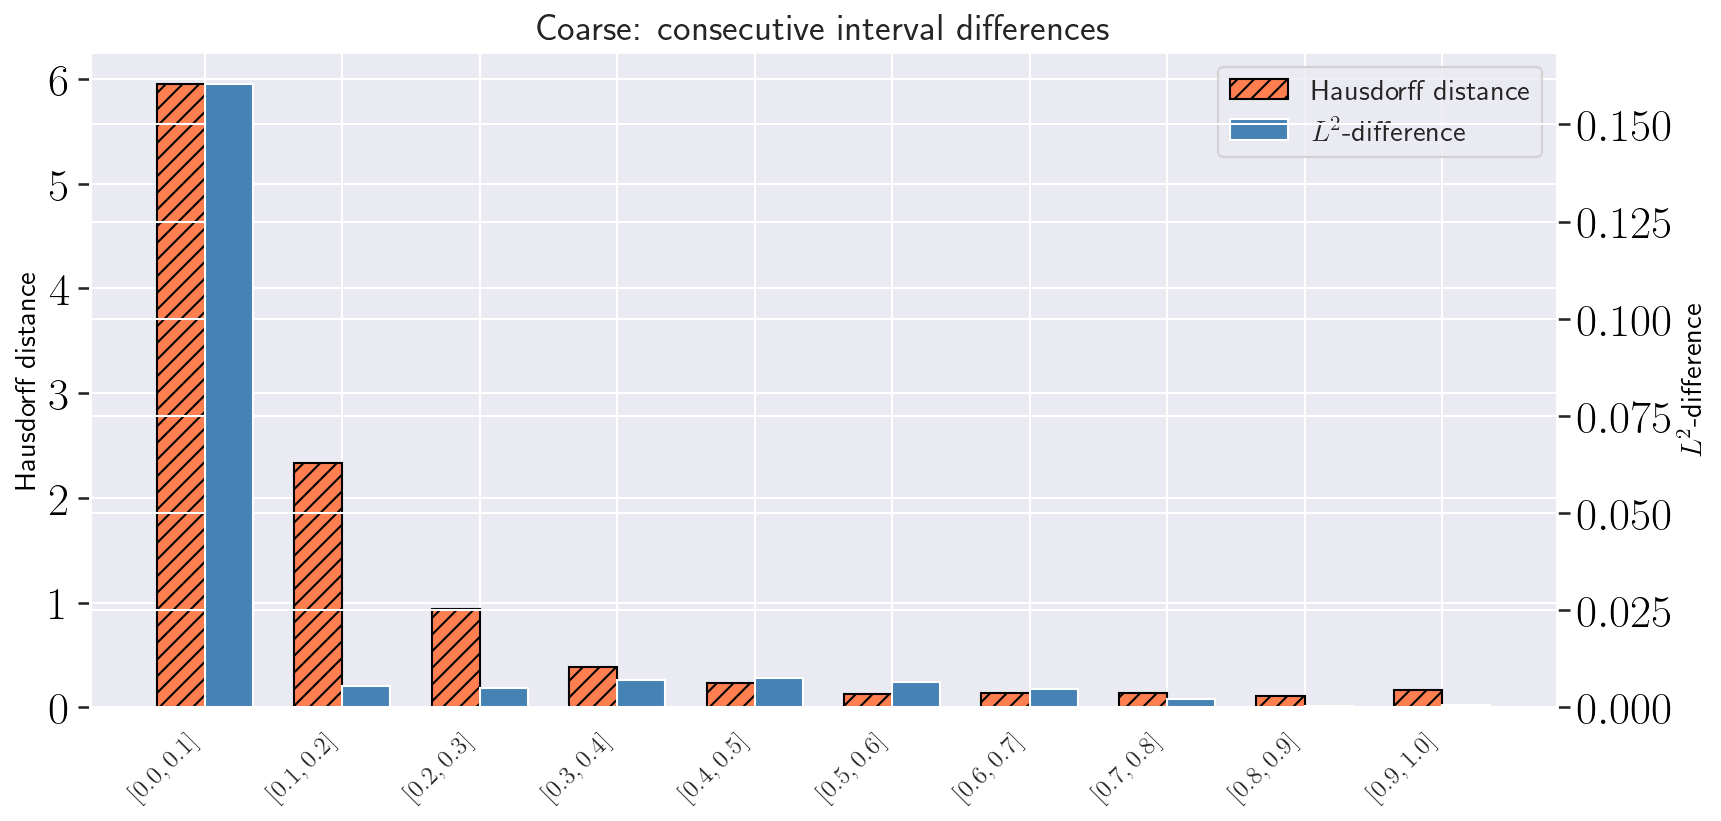

In [11]:
# L2 and Hausdorff difference between consecutive coarse time-step value functions
from scipy.spatial.distance import directed_hausdorff
import numpy as np

path = lqsc.path.clone().detach()
time_steps = sorted(set(path[:, 0].numpy().round(5)))

x_ranges = {}
x_data = {}
for t_val in time_steps:
    mask = torch.abs(path[:, 0] - t_val) < 1e-3
    xs = path[mask, 1]
    x_ranges[t_val] = (xs.min().item(), xs.max().item())
    x_data[t_val] = xs.numpy().reshape(-1, 1)

mse_list = []
hausdorff_list = []
labels = []
num_grid = 200
for i in range(len(time_steps) - 1):
    t0, t1_val = time_steps[i], time_steps[i + 1]
    x_lo = max(x_ranges[t0][0], x_ranges[t1_val][0])
    x_hi = min(x_ranges[t0][1], x_ranges[t1_val][1])
    x_grid = torch.linspace(x_lo, x_hi, num_grid)
    tx0 = torch.cat((t0 * torch.ones(num_grid, 1), x_grid.unsqueeze(-1)), dim=1)
    tx1 = torch.cat((t1_val * torch.ones(num_grid, 1), x_grid.unsqueeze(-1)), dim=1)
    v0 = lqsc.value(tx0).squeeze(-1).detach()
    v1 = lqsc.value(tx1).squeeze(-1).detach()
    mse = torch.mean((v0 - v1) ** 2).item()
    mse_list.append(mse)
    d_fwd = directed_hausdorff(x_data[t0], x_data[t1_val])[0]
    d_bwd = directed_hausdorff(x_data[t1_val], x_data[t0])[0]
    hausdorff_list.append(max(d_fwd, d_bwd))
    labels.append(f"$[{t0:.1f},{t1_val:.1f}]$")
    print(f"t={t0:.2f} vs t={t1_val:.2f}: MSE={mse:.6f}, Hausdorff={hausdorff_list[-1]:.6f}")

x_pos = np.arange(len(labels))
width = 0.35
fig, ax1 = plt.subplots(figsize=(12, 6), dpi=150)
ax2 = ax1.twinx()

bars_haus = ax1.bar(x_pos - width/2, hausdorff_list, width, label='Hausdorff distance',
                     color='coral', hatch='///', edgecolor='black')
bars_l2 = ax2.bar(x_pos + width/2, mse_list, width, label=r"$L^2$-difference", color='steelblue')

ax1.set_ylabel('Hausdorff distance', fontsize=14, color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax2.set_ylabel(r"$L^2$-difference", fontsize=14, color='black')
ax2.tick_params(axis='y', labelcolor='black')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=12)
ax1.set_title('Coarse: consecutive interval differences', fontsize=18)

bars = [bars_haus, bars_l2]
ax1.legend(bars, [b.get_label() for b in bars], fontsize=14, loc='upper right')

plt.tight_layout()
plt.savefig("L2_diff_consecutive_coarse" + version + ".pdf", format='pdf')
plt.show()

In [12]:
# Hausdorff for coarse merged into cell above

In [13]:
K1 = 20
L = 10
X1 = torch.linspace(-2.,2.,K1)
T = torch.zeros([K1,1])
tx1 = torch.concat((T,X1.unsqueeze(-1)),dim=1)
dfv_co = pd.DataFrame(np.zeros([K1*L,2]),columns=[1,'closed']); 
for i,_ in dfv_co.iterrows(): 
    for c in dfv_co.columns:
        if c != 'closed':
            dfv_co.loc[i,c] = lqsc.cost_eval(lqsc.policy,1,X1[i%K1],policy_update_lag=c).clone().detach().numpy()
dfv_co['closed'] = list(solution(tx1))*L
dfv_co['index'] = [str(np.round(x,3)) for x in X1.clone().detach().numpy()]*L
dfv_co.set_index('index',inplace=True,drop=True)
dfv_co


/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/1048887168.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.f_func = lambda t: -1/q2*(lb1*np.exp(lb1*(self.T-t))+C1*lb2*np.exp(lb2*(self.T-t)))/(np.exp(lb1*(self.T-t))+C1*np.exp(lb2*(self.T-t)))
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/1048887168.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.array([self.f_func(tx[i,0])*np.power(tx[i,1],2)+self.h_func(tx[i,0])*tx[i,1]+self.k_func(tx[i,0]) for i in range(tx.shape[0])])
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/1048887168.py:34: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.h_func = lambda t: (self.b*((1/(lb1-self.c))*np.exp(lb

,1,closed
index,,
-2.0,6.557754,4.665618
-1.789,6.463187,3.765499
-1.579,4.602691,2.968311
-1.368,4.582078,2.274053
-1.158,2.567929,1.682726
...,...,...
1.158,2.632118,1.971560
1.368,4.114253,2.615402
1.579,5.995156,3.362174


/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/2703621577.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(list(np.round(X1.clone().detach().numpy(),2)));
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/2703621577.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="right");


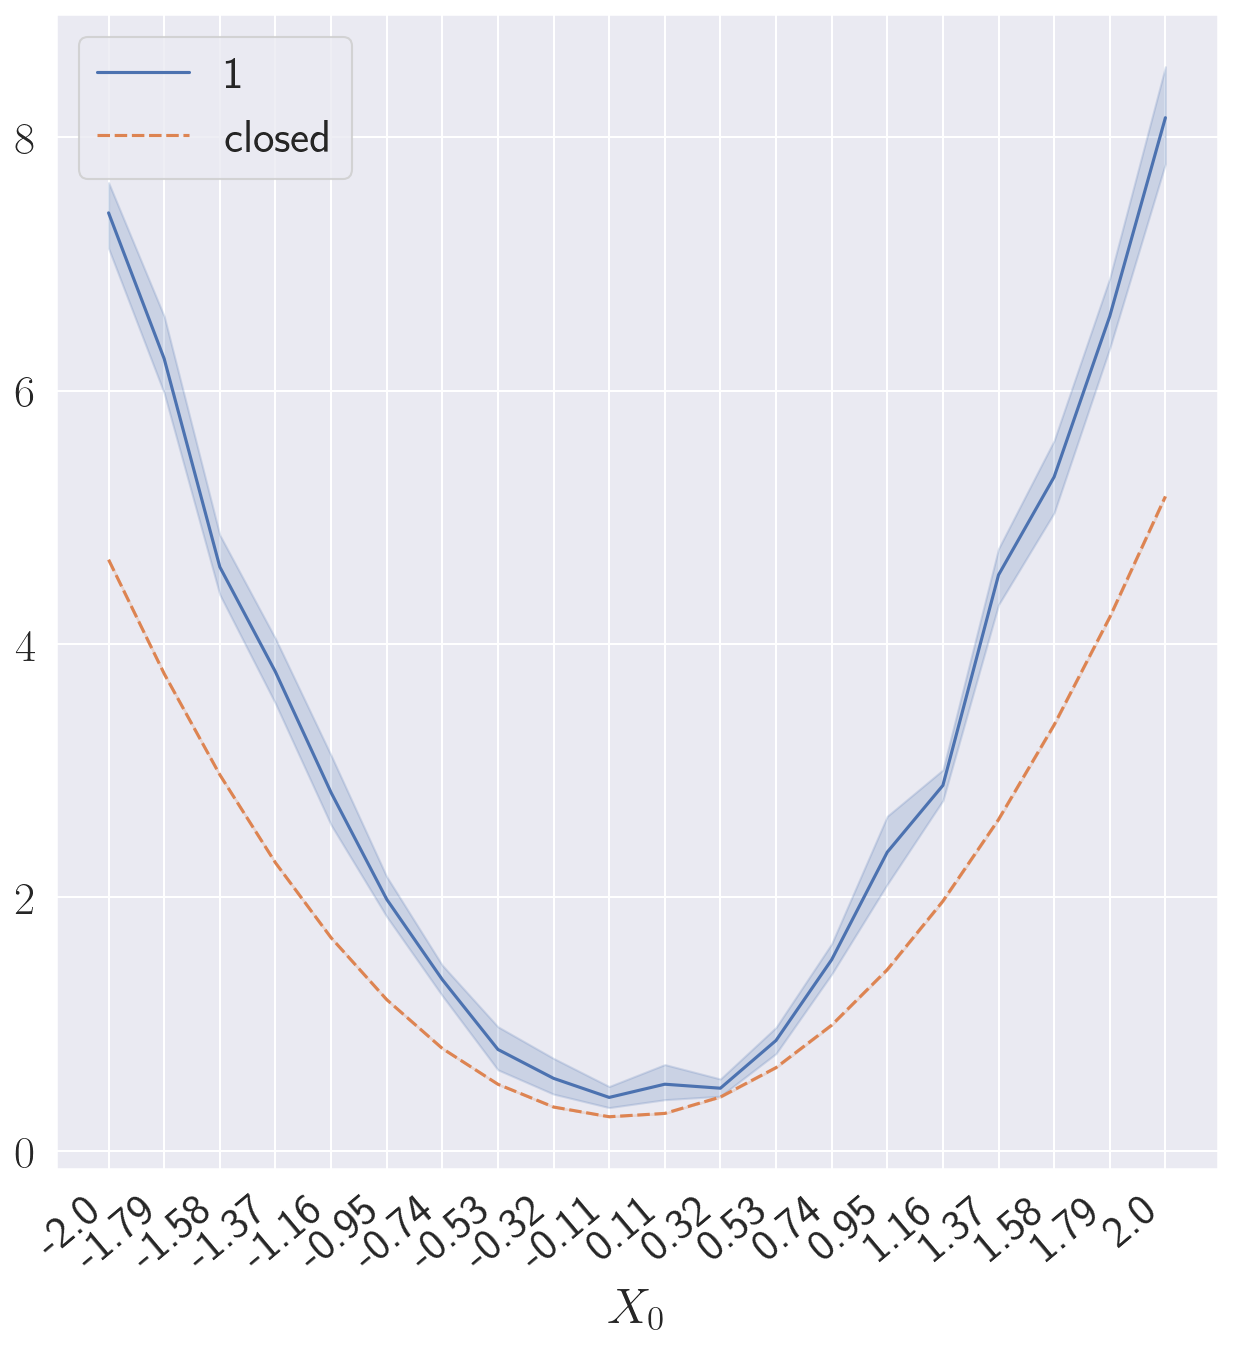

In [14]:
fig = plt.figure(figsize=(10,10),dpi=150);
g = sns.lineplot(data=dfv_co);
g.set_xticklabels(list(np.round(X1.clone().detach().numpy(),2)));
g.set_xlabel(r"$X_0$");
g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="right");



In [15]:
K = 10
L = 10
X = torch.linspace(-10.,10.,K)
T = torch.zeros([K,1])
tx = torch.concat((T,X.unsqueeze(-1)),dim=1)
df_co = pd.DataFrame(np.zeros([K*L,2]),columns=[1,'closed']); 
for i,_ in df_co.iterrows(): 
    for c in df_co.columns:
        if c != 'closed':
            df_co.loc[i,c] = lqsc.cost_eval(lqsc.policy,1,X[i%K],policy_update_lag=c).clone().detach().numpy()
df_co['closed'] = list(solution(tx))*L
df_co['index'] = [str(np.round(x,3)) for x in X.clone().detach().numpy()]*L
df_co.set_index('index',inplace=True,drop=True)
df_co


/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/1048887168.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.f_func = lambda t: -1/q2*(lb1*np.exp(lb1*(self.T-t))+C1*lb2*np.exp(lb2*(self.T-t)))/(np.exp(lb1*(self.T-t))+C1*np.exp(lb2*(self.T-t)))
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/1048887168.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.array([self.f_func(tx[i,0])*np.power(tx[i,1],2)+self.h_func(tx[i,0])*tx[i,1]+self.k_func(tx[i,0]) for i in range(tx.shape[0])])
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/1048887168.py:34: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.h_func = lambda t: (self.b*((1/(lb1-self.c))*np.exp(lb

,1,closed
index,,
-10.0,188.778831,115.141822
-7.778,109.684628,69.544915
-5.556,55.795600,35.416525
-3.333,21.589538,12.756653
-1.111,2.366589,1.565299
...,...,...
1.111,2.848315,1.842462
3.333,22.410770,13.588143
5.556,57.895113,36.802342


In [16]:
df_box_co = ((df_co[1]-df_co['closed'])/df_co['closed']).reset_index()
df_box_co.columns = ['x', 'rel_error']
df_box_co['Method'] = 'coarse'

/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/3061354558.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(list(np.round(X.clone().detach().numpy(),2)));
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/3061354558.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="center");


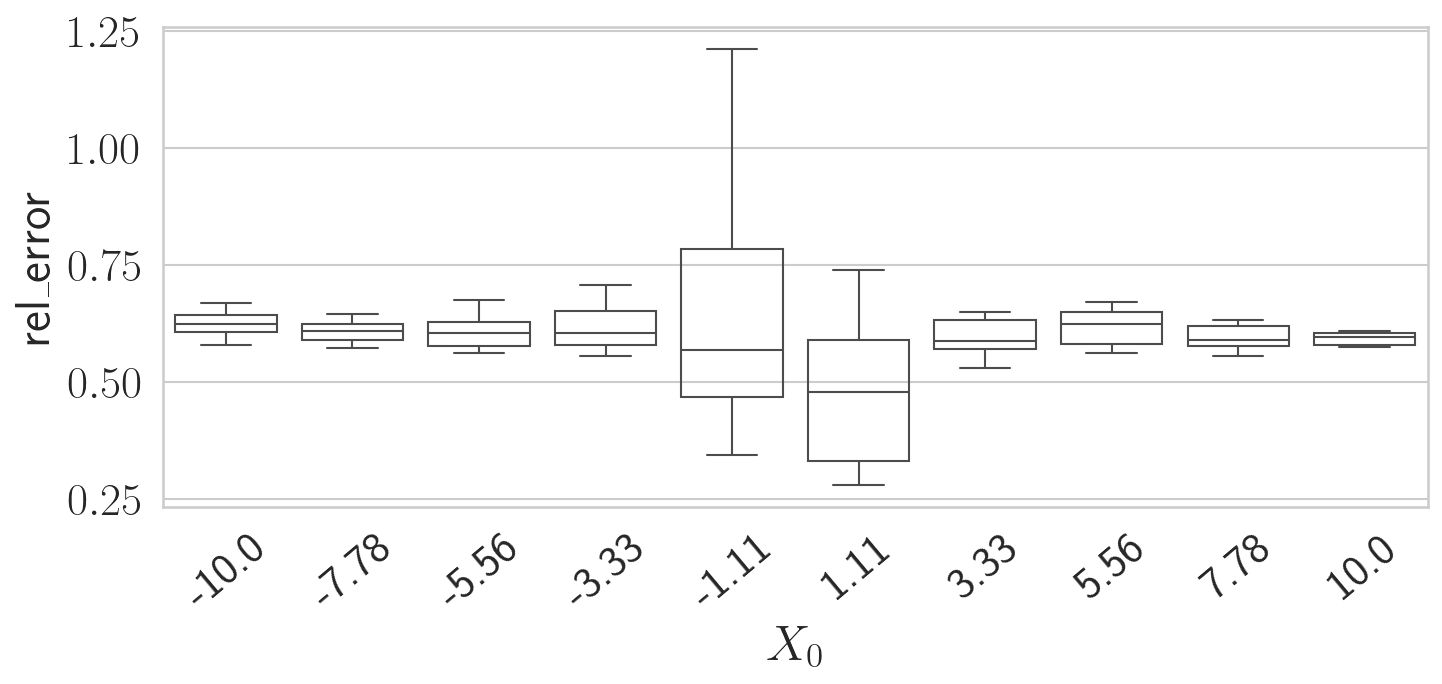

In [17]:
fig = plt.figure(figsize=(10,5),dpi=150);
sns.set_style("whitegrid");
g = sns.boxplot(data=df_box_co, y = 'rel_error', x = 'x', boxprops=dict(facecolor='none'));
g.set_xticklabels(list(np.round(X.clone().detach().numpy(),2)));
g.set_xlabel(r"$X_0$");
g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="center");
plt.tight_layout();


In [18]:
lqsc.train_val_fnc(num_epochs=12000)

Last training epoch was 1993
value function training time= 0.6705598831176758


Relative $L^1$ error $= 59.72\%$

Relative $L^2$ error $= 59.70\%$

Relative $L^\infty$ error $= 58.06\%$

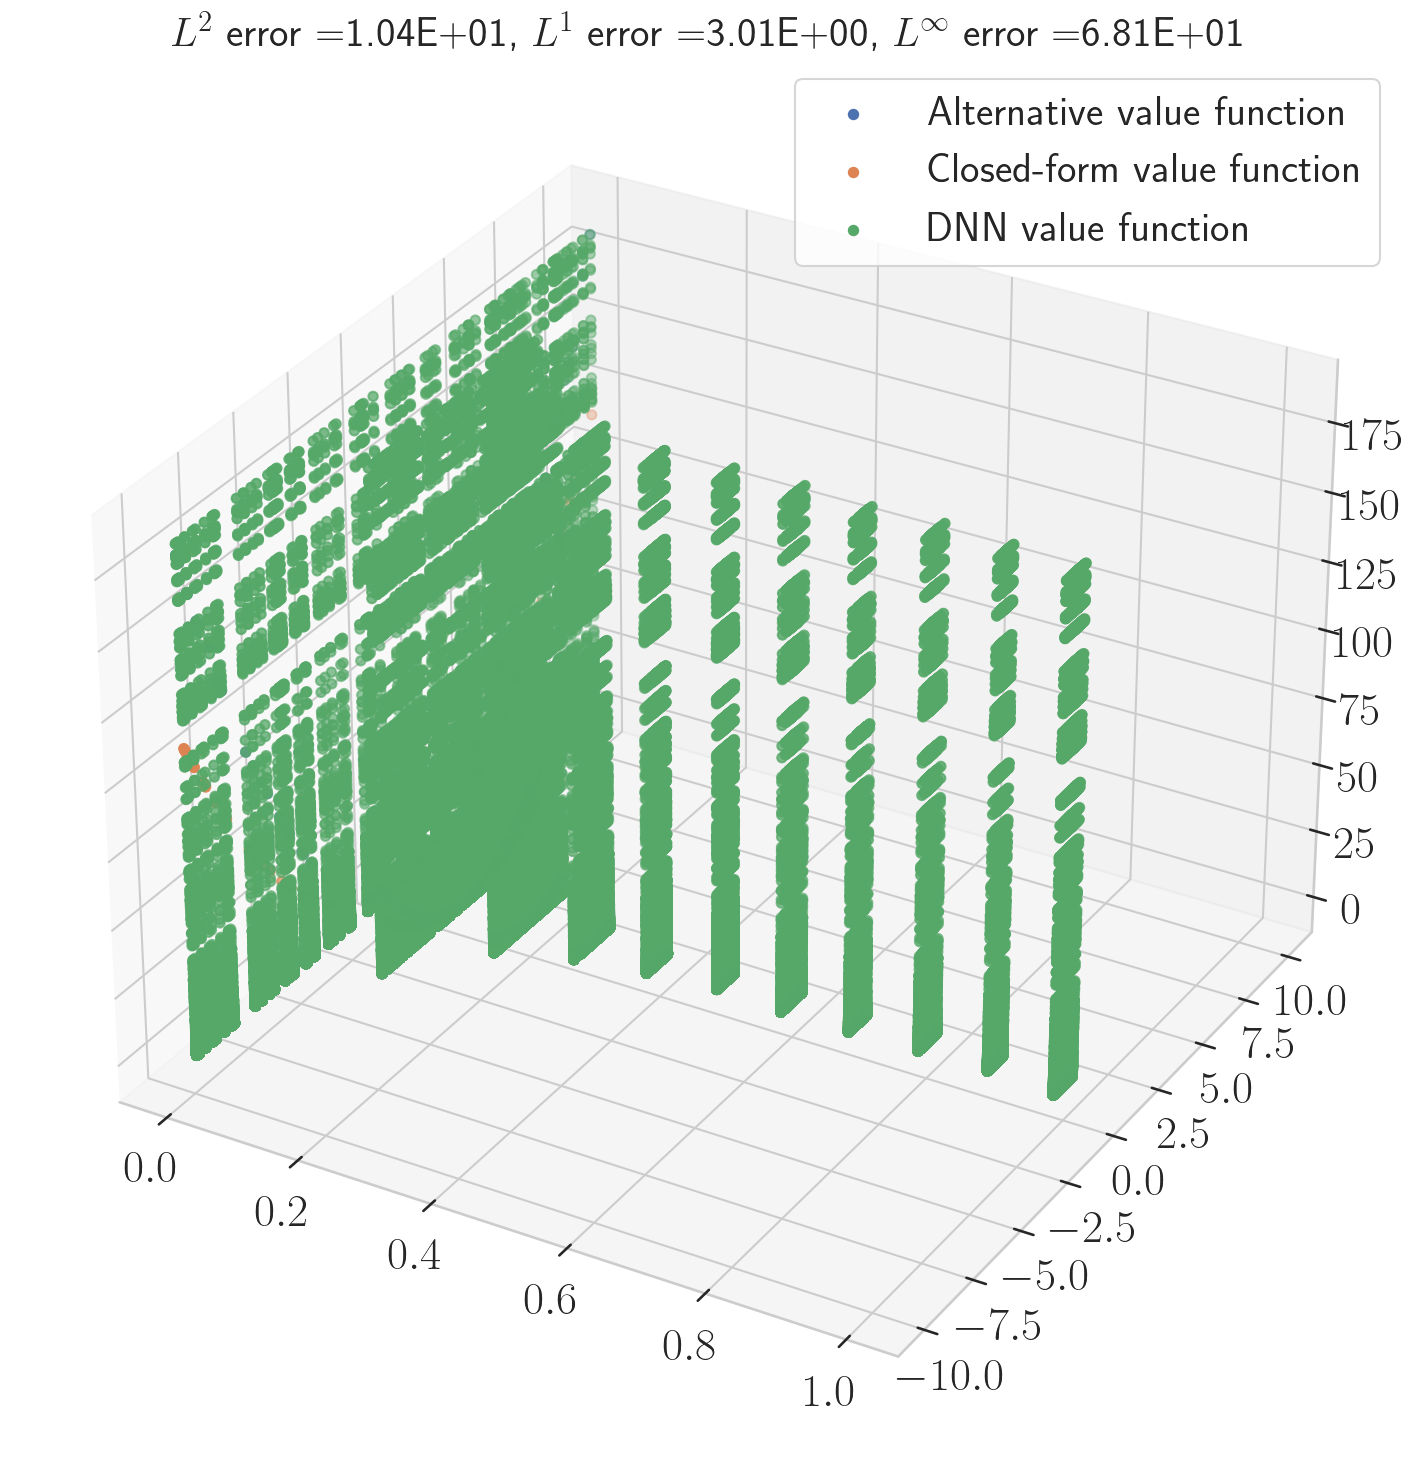

In [19]:
xyz = torch.concat((lqsc.path,lqsc(lqsc.path).unsqueeze(-1)),dim=1).clone().detach().numpy()
v = lqsc.value(lqsc.path).unsqueeze(-1).clone().detach().numpy()
fig = plt.figure(figsize=(12, 12), dpi=150)
ax = fig.add_subplot(projection='3d')
ax.scatter(xyz[:,0], xyz[:,1], xyz[:,2],label='Alternative value function')
ax.scatter(xyz[:,0], xyz[:,1], solution(xyz[:,0:2]),label='Closed-form value function')
ax.scatter(xyz[:,0], xyz[:,1], v,label='DNN value function')

ax.set_title(r"$L^2$ error ={:.2E}, $L^1$ error ={:.2E},  $L^\infty$ error ={:.2E}".format(np.sqrt(np.mean(np.power(solution(xyz[:,0:2])-xyz[:,2],2))),
                                                                                           np.mean(np.abs(solution(xyz[:,0:2])-xyz[:,2])),
                                                                                           np.max(np.abs(solution(xyz[:,0:2])-xyz[:,2]))
                                                                                           ), fontsize=20)
# ax.view_init(elev=30, azim=45, roll=0)
ax.legend(prop=font);
display(Markdown(r"Relative $L^1$ error $= {:.2f}\%$".format(np.mean(np.abs(solution(xyz[:,0:2])-xyz[:,2]))/np.mean(np.abs(solution(xyz[:,0:2])))*100)))
display(Markdown(r"Relative $L^2$ error $= {:.2f}\%$".format(np.sqrt(np.mean(np.power(solution(xyz[:,0:2])-xyz[:,2],2)))/np.sqrt(np.mean(np.power(solution(xyz[:,0:2]),2)))*100)))
display(Markdown(r"Relative $L^\infty$ error $= {:.2f}\%$".format(np.max(np.abs(solution(xyz[:,0:2])-xyz[:,2]))/np.max(np.abs(solution(xyz[:,0:2])))*100)))

/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/1048887168.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.f_func = lambda t: -1/q2*(lb1*np.exp(lb1*(self.T-t))+C1*lb2*np.exp(lb2*(self.T-t)))/(np.exp(lb1*(self.T-t))+C1*np.exp(lb2*(self.T-t)))
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/1048887168.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.array([self.f_func(tx[i,0])*np.power(tx[i,1],2)+self.h_func(tx[i,0])*tx[i,1]+self.k_func(tx[i,0]) for i in range(tx.shape[0])])
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/1048887168.py:34: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.h_func = lambda t: (self.b*((1/(lb1-self.c))*np.exp(lb

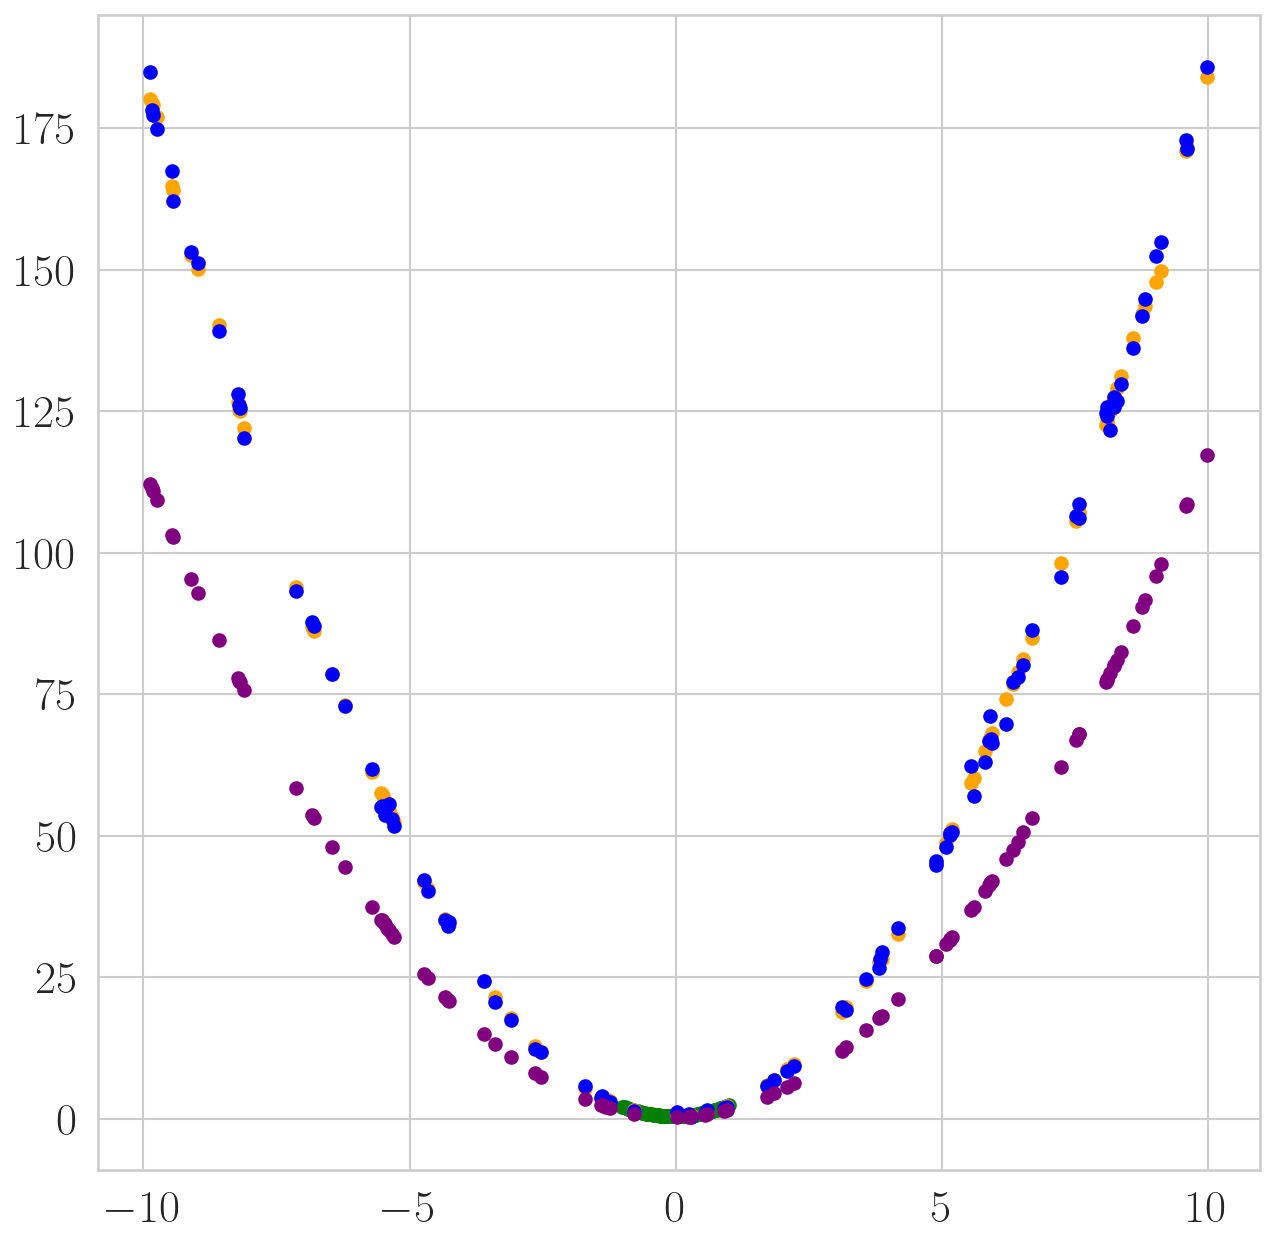

In [20]:
fig = plt.figure(figsize=(10, 10), dpi=150)
x = torch.linspace(-1.,1.,100)
t = torch.Tensor([0.0])
plt.scatter(x = x.clone().detach().numpy(),y = lqsc.alt_value(500,t,x).clone().detach().numpy(),color='green') 
x = lqsc.path
y = lqsc.value(x)
z = lqsc.path_cost
ind = torch.abs(x[:,0]-t)<1e-3
plt.scatter(x[ind][:,1].clone().detach().numpy(),y[ind].clone().detach().numpy(),color='orange')
plt.scatter(x[ind][:,1].clone().detach().numpy(),z[ind].clone().detach().numpy(),color='blue');
plt.scatter(x[ind][:,1].clone().detach().numpy(),solution(x[ind]),color='purple');

# Multi-scale PGM

## Multi-scale parameters

In [21]:
ms1_model_params = {
    'num_samples':50,
    'num_time_steps':10,
    'num_neurons_p':50,
    'num_neurons_v':10,
    'lr' : 8e-3,
    'num_epochs' : 3000,
    'xmin' : model_params['xmin'],
    'xmax' : model_params['xmax'],
    'intervals' : [[k*lqsc.T/lqsc.num_time_steps, (k+1)*lqsc.T/lqsc.num_time_steps] for k in range(3)], # first 3 intervals
    'data': lqsc.path
    }

In [22]:
ms1_model_params['intervals']

[[0.0, 0.1], [0.1, 0.2], [0.2, 0.3]]

## Multi-scale class

In [23]:
class multi_scale_pgm(object):
    def __init__(self, model_params, lqsc_params, parent, **kwarg):
        self.value_eval = kwarg.get('value_eval', True)
        self.num_samples = model_params['num_samples']
        self.num_time_steps = model_params['num_time_steps']
        self.num_neurons_p = model_params['num_neurons_p']
        self.num_neurons_v = model_params['num_neurons_v']
        self.lr = model_params['lr']
        self.num_epochs = model_params['num_epochs']
        self.x0 = model_params['xmin']
        self.x1 = model_params['xmax']
        self.intervals = [[0,1.]] if model_params['intervals']== None else model_params['intervals']
        self.num_intervals = len(self.intervals)
        self.parent = parent#lambda tx: self.alpha*torch.pow(tx[:,1],2)+self.beta*tx[:,1]+self.gamma
        self.T = self.parent.T
        self.delta = parent.delta/self.num_time_steps
        self.Num_steps = self.parent.Num_steps*self.num_time_steps
        self.a=lqsc_params['a']
        self.b=lqsc_params['b']
        self.c=lqsc_params['c']
        self.d=lqsc_params['d']
        self.A=lqsc_params['A']
        self.B=lqsc_params['B']
        self.sigma=lqsc_params['sigma']
        self.alpha=lqsc_params['alpha']
        self.beta=lqsc_params['beta']
        self.gamma=lqsc_params['gamma']
        self.init_data = model_params['data']
        self.proper_int = lambda t: int((self.T-t)/self.delta)+1 if (self.T-t)/self.delta - int((self.T-t)/self.delta) > self.delta/2 else int((self.T-t)/self.delta)



        self.model= torch.nn.Sequential(
            torch.nn.Linear(2, self.num_neurons_p),
            torch.nn.ReLU(),
            torch.nn.Linear(self.num_neurons_p, self.num_neurons_p),
            torch.nn.ReLU(),
            torch.nn.Linear(self.num_neurons_p,1)
        )
        self.value= torch.nn.Sequential(
            torch.nn.Linear(2, self.num_neurons_v),
            torch.nn.ReLU(),
            torch.nn.Linear(self.num_neurons_v, self.num_neurons_v),
            torch.nn.ReLU(),
            torch.nn.Linear(self.num_neurons_v,1)
        )
        
    
    def gen_data(self):
        if self.intervals == [[0,1.]]:
            self.t=torch.zeros([self.num_samples,self.num_intervals])
            #z=np.zeros([M,ite+1])+np.random.rand(M,1)
            # self.z= torch.normal(0, 1, size=(self.num_samples,self.num_time_steps+1))
            self.x_train=torch.FloatTensor(self.num_samples,1).uniform_(self.x0,self.x1)   #remaining balance R_t   #To get a positive solution R_t has to be greater than D_t
            self.data=torch.cat((self.t,self.x_train),dim=1)
        else:
            x = self.init_data
            for i,I in enumerate(self.intervals):
                if i==0:
                    data = x[torch.abs(x[:,0]-I[0])<1e-3][:,1]
                    a = torch.quantile(data, 0.1, interpolation='linear')
                    b = torch.quantile(data, 0.9, interpolation='linear')
                    self.t=I[0]*torch.ones([self.num_samples,1])
                    self.x_train=torch.FloatTensor(self.num_samples,1).uniform_(a,b)
                    self.data=torch.cat((self.t,self.x_train),dim=1)
                else:
                    data = x[torch.abs(x[:,0]-I[0])<1e-2]
                    a = torch.quantile(data, 0.1, interpolation='linear')
                    b = torch.quantile(data, 0.9, interpolation='linear')
                    self.t=I[0]*torch.ones([self.num_samples,1])
                    self.x_train=torch.FloatTensor(self.num_samples,1).uniform_(a,b)
                    data = torch.cat((self.t,self.x_train),dim=1)
                    self.data = torch.concat((self.data,data))
        self.z= torch.normal(0, 1, size=(self.data.shape[0],self.num_time_steps+1))

    
    def update(self,x3,psi,i):
        t=(x3[:,0]+self.delta)
        x=x3[:,1]+(self.c*x3[:,1]+self.d*psi)*self.delta+self.sigma*torch.sqrt(self.delta)*self.z[:,i]
        up=torch.cat((t.unsqueeze(1),x.unsqueeze(1)),dim=1)
        return up

    def loss_func(self,x2,psi):
        loss=self.a*torch.pow(x2[:,1],2)+self.b*x2[:,1]+self.A*torch.pow(psi,2)+self.B*psi
        return loss

    def loss_func_ter(self,x4):
        # loss=self.alpha*torch.pow(x4[:,1],2)+self.beta*x4[:,1]
        return self.parent(x4)#loss

    def unit(self,x1,i,policy, **kwargs):
        x2 = kwargs.get('disc_policy', x1)
        psi=policy(x2).squeeze(1)
        loss=self.loss_func(x1,psi)
        upd=self.update(x1,psi,i)
        #print('unit print=',psi.shape,los.shape,upd.shape)
        return psi,loss,upd

    def loss_func_total(self,epoch):
        u = self.data
        path = torch.zeros(self.num_samples*self.num_intervals,self.num_time_steps+1,2)
        path_loss=torch.zeros(self.num_samples*self.num_intervals,self.num_time_steps+1)# (i,j)-> (i+1)j
        psi=torch.zeros(self.num_samples*self.num_intervals,self.num_time_steps)
        if (epoch==self.num_epochs-1):
            self.state_var=u.clone().detach()   
            path[:,0,:] = u.clone().detach()
        for i in range(self.num_time_steps):
            psi_run,loss_run,u_run=self.unit(u,i,self.model)
            #print('los func=',psi_run.shape,loss_run.shape)
            path_loss[:,i]=loss_run*self.delta
            #print(loss)
            psi[:,i]=psi_run
            #print(psi)
            u=u_run
            if (epoch==self.num_epochs-1):
                self.state_var = torch.concat((self.state_var,u.clone().detach()), axis=0)  
                path[:,i+1,:] = u.clone().detach()     
        path_loss[:,-1]=self.loss_func_ter(u)
        if (epoch==self.num_epochs-1):
            a = torch.flip(path_loss, dims = (1,))
            b = torch.cumsum(a, dim=1)
            c = torch.flip(b, dims = (1,))
            d = torch.transpose(c,0,1)
            self.path_cost = d.reshape(self.num_intervals*(self.num_time_steps+1)*self.num_samples,1).clone().detach()
            p = torch.transpose(path,0,1)
            self.path = p.reshape(self.num_intervals*(self.num_time_steps+1)*self.num_samples,2).clone().detach()            
        loss_=torch.sum(path_loss,dim=1)
        return loss_
    
    def train_it(self):
        self.gen_data()
        start=time.time()
        cost_ar=[]
        optimizer = optim.Adam(self.model.parameters(), self.lr)
        for epoch in range(self.num_epochs):
            optimizer.zero_grad()
            cost = self.loss_func_total(epoch)
            loss = torch.mean(cost)
            loss.backward()
            optimizer.step()
            cost_ar.append(loss)
            #print(loss.item())
            if (epoch % 500==0):
                print("At epoch {} the mean cost is {}.".format(epoch,loss.detach()))
        end=time.time()
        total_time=end-start
        self.train_time = total_time
        self.train_epochs = epoch + 1
        self.final_cost = loss.item()
        print('Training time=',total_time)
        self.path_full, self.path_cost_full = self.optimal_path(self.parent.num_samples)

        if self.value_eval:
            self.train_val_fnc()


    def train_val_fnc(self,**kwargs):
        M = kwargs.get('num_epochs', self.num_epochs)
        K = kwargs.get('num_samples', self.num_samples)
        permuted_range = np.random.permutation(self.num_intervals*(self.num_time_steps+1)*self.num_samples)
        tx = self.path[permuted_range,:]
        val = self.path_cost[permuted_range,:]
        optimizer_v = optim.Adam(self.value.parameters(), self.lr)
        start=time.time()
        E_ = -1e9
        E = 1e9
        m = 0
        while (np.abs((E-E_)/E_)>1e-4) and ( m <= M):
            loss_v = torch.nn.MSELoss()(self.value(tx),val)
            optimizer_v.zero_grad()
            loss_v.backward()
            optimizer_v.step()
            m += 1
        end=time.time()
        total_time=end-start
        self.value_time = total_time
        self.value_epochs = m
        self.final_value_loss = loss_v.item()
        print('value function training time=',total_time)        
        
    # def __call__(self, tx):
    #     return self.value(tx).squeeze(-1)
    
    def policy(self,tx):
        return self.model(tx)    
        
    def optimal_path(self,num_samples):
        N = self.Num_steps+1
        path = torch.zeros(num_samples,N,2)
        path_loss=torch.zeros(num_samples,N)
        t=torch.zeros([num_samples,1])
        self.z= torch.normal(0, 1, size=(num_samples,N))
        x=torch.FloatTensor(num_samples,1).uniform_(self.x0,self.x1)   #remaining balance R_t   #To get a positive solution R_t has to be greater than D_t
        path[:,0,:] = torch.cat((t,x),dim=1).clone().detach()
        for i in range(N-1):
            _,loss_run,u_run=self.unit(path[:,i,:],i,self.model)
            path[:,i+1,:] = u_run.clone().detach() 
            path_loss[:,i]=loss_run*self.delta   
        path_loss[:,-1]=self.loss_func_ter(u_run)
        p = torch.transpose(path,0,1)
        path = p.reshape(num_samples*N,2).clone().detach()   
        a = torch.flip(path_loss, dims = (1,))
        b = torch.cumsum(a, dim=1)
        c = torch.flip(b, dims = (1,))
        d = torch.transpose(c,0,1)
        path_cost = d.reshape(num_samples*N,1).clone().detach()         
        return path, path_cost
        

    def cost_eval(self,policy,num_samples,x0, **kwargs):
        M = kwargs.get('policy_update_lag', 1)
        if  self.Num_steps%M!=0:
            raise ValueError(r"The number of time steps {:d} in this PGM instance must be divisible by the number of time steps {:d} in the input of disc_cost_eval(self,policy,num_samples,num_time_steps,x0).".format(self.num_time_steps,M))
        else:
            N = self.Num_steps+1
            val=torch.zeros([num_samples])
            t=torch.zeros([num_samples,1])
            self.z= torch.normal(0, 1, size=(num_samples,N))
            x = x0*torch.ones([num_samples,1])
            full_path = torch.zeros(num_samples,N,2)
            full_path[:,0,:] = torch.cat((t,x),dim=1).clone().detach()
            for i in range(N-1):
                last_coarse_point = full_path[:,int(i/M),:]
                _,loss_run,u_run=self.unit(full_path[:,i,:],i,policy,disc_policy = last_coarse_point)
                full_path[:,i+1,:] = u_run.clone().detach() 
                val += (loss_run*self.delta).clone().detach()
            val += self.parent.loss_func_ter(u_run).clone().detach()
            return torch.mean(val)     
        
        
   # We need the policy to only be evaluated at discrete points and stays unchanged until the next point.
    def alt_value(self,num_samples,t,x):
        M = x.shape[0]
        x0 = x.repeat(num_samples).unsqueeze(-1)
        t0 = t.repeat(num_samples*M).unsqueeze(-1)
        N = self.proper_int(t)
        full_path = torch.zeros(num_samples*M,N+1,2)
        # full_path_loss=torch.zeros(M,num_samples,N)
        self.z= torch.normal(0, 1, size=(M*num_samples,N))
        val=torch.zeros(num_samples*M)
        full_path[:,0,:] = torch.cat((t0,x0),dim=1).clone().detach()
        if N==0:
            u_run = full_path[:,0,:]
        else:
            for i in range(N):
                _,loss_run,u_run=self.unit(full_path[:,i,:],i,self.policy)
                full_path[:,i+1,:] = u_run.clone().detach() 
                val += (loss_run*self.delta).clone().detach()
        val += self.loss_func_ter(u_run).clone().detach()
        w = torch.reshape(val,[num_samples,M])
        return torch.mean(w,axis=0)

    def __call__(self, tx, **kwargs):
        num_samples = kwargs.get('num_samples',500)
        t_set = set(tx[:,0].clone().detach().numpy())
        val = torch.zeros(tx.shape[0])
        for ti in t_set:
            ind = tx[:,0] == ti
            if ti>=self.T-self.delta/2:
                val[ind] = self.loss_func_ter(tx[ind]).clone().detach()
            else:
                val[ind] = self.alt_value(num_samples,torch.tensor(ti),tx[ind][:,1])
        return val                
         
    

## instance creation

In [24]:
ms1 = multi_scale_pgm(ms1_model_params,lqsc_params, lqsc, value_eval=False)

## Training

In [25]:
ms1.train_it()

At epoch 0 the mean cost is 29.55179477771242.


At epoch 500 the mean cost is 11.258397857635162.


At epoch 1000 the mean cost is 11.25642070359998.


At epoch 1500 the mean cost is 11.254652120152647.


At epoch 2000 the mean cost is 11.251639351122503.


At epoch 2500 the mean cost is 11.248013710018814.


Training time= 6.074325084686279


In [26]:
dfv_ms = pd.DataFrame(np.zeros([K1*L,3]),columns=[1,'C','closed']); 
for i,_ in dfv_ms.iterrows(): 
    dfv_ms.loc[i,1] = ms1.cost_eval(ms1.policy,1,X1[i%K1]).clone().detach().numpy()
    dfv_ms.loc[i,'C'] = lqsc.cost_eval(lqsc.policy,1,X1[i%K1]).clone().detach().numpy()
dfv_ms['closed'] = list(solution(tx1))*L
dfv_ms['index'] = [str(np.round(x,3)) for x in X1.clone().detach().numpy()]*L
dfv_ms.set_index('index',inplace=True,drop=True)
dfv_ms


/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/1048887168.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.f_func = lambda t: -1/q2*(lb1*np.exp(lb1*(self.T-t))+C1*lb2*np.exp(lb2*(self.T-t)))/(np.exp(lb1*(self.T-t))+C1*np.exp(lb2*(self.T-t)))
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/1048887168.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.array([self.f_func(tx[i,0])*np.power(tx[i,1],2)+self.h_func(tx[i,0])*tx[i,1]+self.k_func(tx[i,0]) for i in range(tx.shape[0])])
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/1048887168.py:34: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.h_func = lambda t: (self.b*((1/(lb1-self.c))*np.exp(lb

,1,C,closed
index,,,
-2.0,4.794056,7.728670,4.665618
-1.789,4.273929,6.486370,3.765499
-1.579,3.435812,4.633785,2.968311
-1.368,2.870901,3.376537,2.274053
-1.158,1.825024,3.502821,1.682726
...,...,...,...
1.158,2.612973,3.367443,1.971560
1.368,3.891319,3.563061,2.615402
1.579,4.252750,4.925540,3.362174


/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/2152127763.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(list(np.round(X1.clone().detach().numpy(),2)));
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/2152127763.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="right")


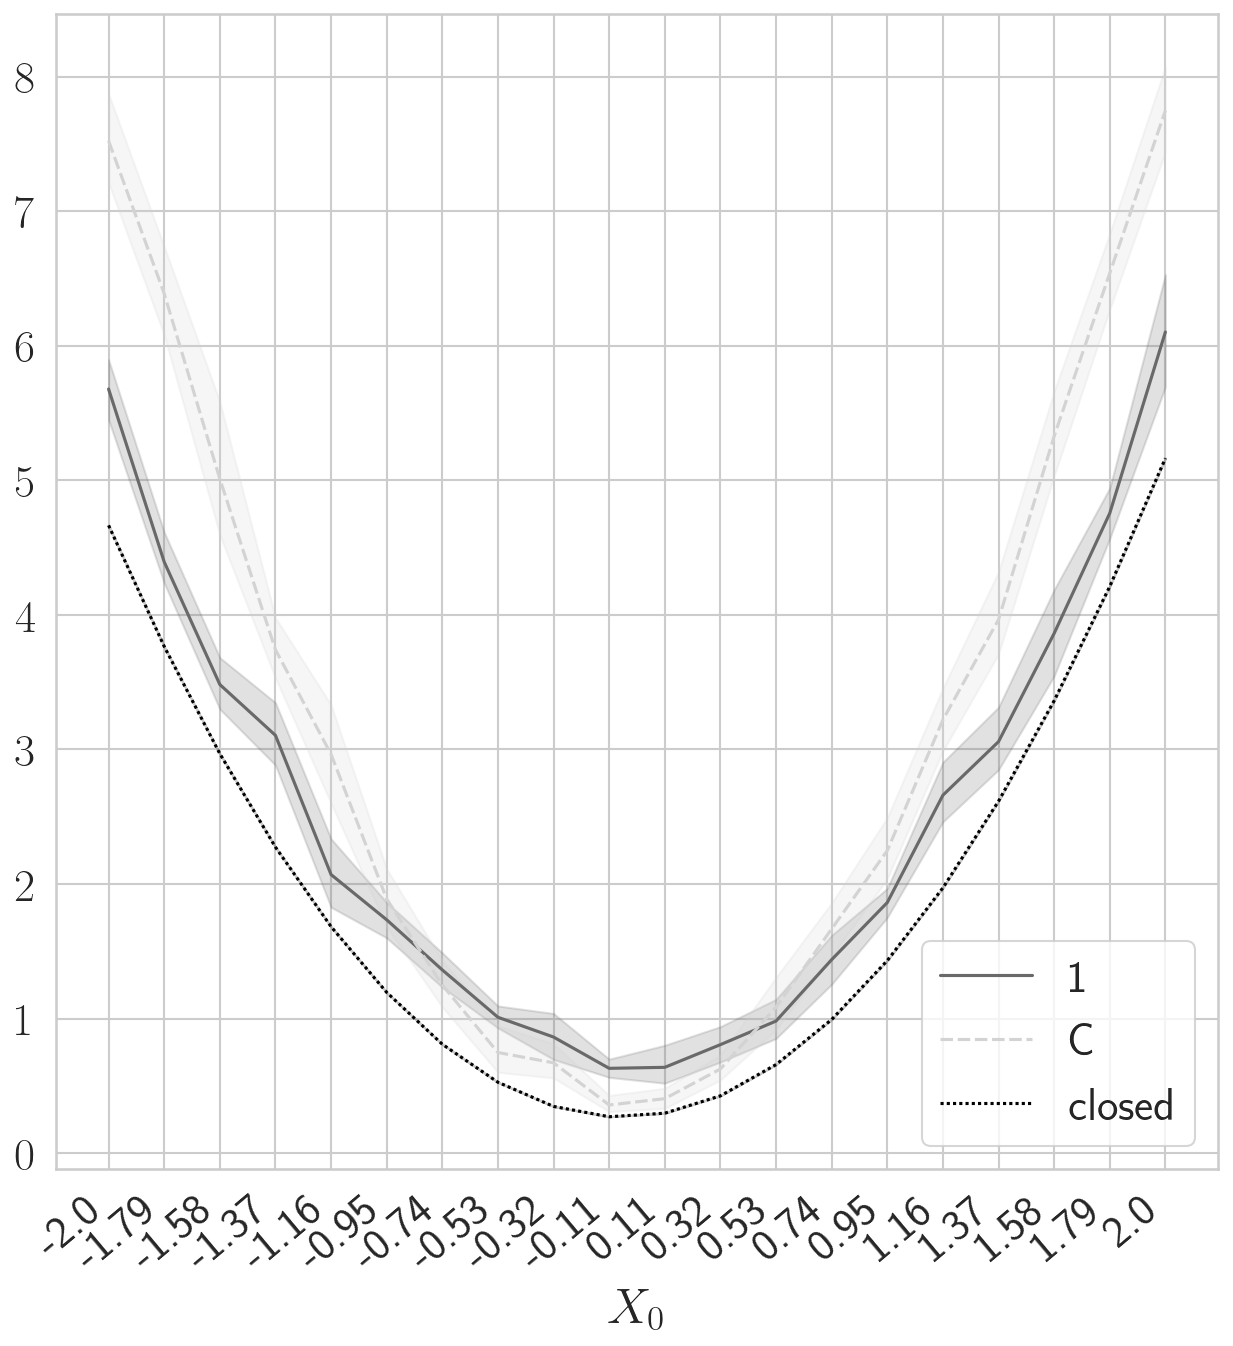

In [27]:
plt.figure(figsize=(10,10),dpi=150);
g = sns.lineplot(data=dfv_ms, palette=['dimgrey', 'lightgrey', 'black']);
g.set_xticklabels(list(np.round(X1.clone().detach().numpy(),2)));
g.set_xlabel(r"$X_0$");
g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="right")
s1 = str(model_params['num_samples'])
s2 = str(ms1_model_params['num_samples'])
plt.savefig(s1+"_"+s2+version+".png")

In [28]:
df_ms = pd.DataFrame(np.zeros([K*L,3]),columns=[1,'C','closed']); 
for i,_ in df_ms.iterrows(): 
    df_ms.loc[i,1] = ms1.cost_eval(ms1.policy,1,X[i%K]).clone().detach().numpy()
    df_ms.loc[i,'C'] = lqsc.cost_eval(lqsc.policy,1,X[i%K]).clone().detach().numpy()
df_ms['closed'] = list(solution(tx))*L
df_ms['index'] = [str(np.round(x,3)) for x in X.clone().detach().numpy()]*L
df_ms.set_index('index',inplace=True,drop=True)
df_ms

/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/1048887168.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.f_func = lambda t: -1/q2*(lb1*np.exp(lb1*(self.T-t))+C1*lb2*np.exp(lb2*(self.T-t)))/(np.exp(lb1*(self.T-t))+C1*np.exp(lb2*(self.T-t)))
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/1048887168.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.array([self.f_func(tx[i,0])*np.power(tx[i,1],2)+self.h_func(tx[i,0])*tx[i,1]+self.k_func(tx[i,0]) for i in range(tx.shape[0])])
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/1048887168.py:34: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.h_func = lambda t: (self.b*((1/(lb1-self.c))*np.exp(lb

,1,C,closed
index,,,
-10.0,119.419877,184.404374,115.141822
-7.778,74.448213,107.822206,69.544915
-5.556,36.048612,57.430142,35.416525
-3.333,15.166690,20.214137,12.756653
-1.111,1.679420,2.446642,1.565299
...,...,...,...
1.111,2.841563,2.689841,1.842462
3.333,14.470601,19.179503,13.588143
5.556,38.385930,57.836259,36.802342


In [29]:
df_box_ms = ((df_ms[1]-df_ms['closed'])/df_ms['closed']).reset_index()
df_box_ms.columns = ['x', 'rel_error']
df_box_ms['Method'] = 'multi-scale'
df_box_msc = pd.concat([df_box_ms,df_box_co],axis=0)
df_box_msc

,x,rel_error,Method
0,-10.0,0.037155,multi-scale
1,-7.778,0.070505,multi-scale
2,-5.556,0.017847,multi-scale
3,-3.333,0.188924,multi-scale
4,-1.111,0.072907,multi-scale
...,...,...,...
95,1.111,0.545929,coarse
96,3.333,0.649289,coarse
97,5.556,0.573137,coarse
98,7.778,0.555693,coarse


/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/3941098221.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="right")


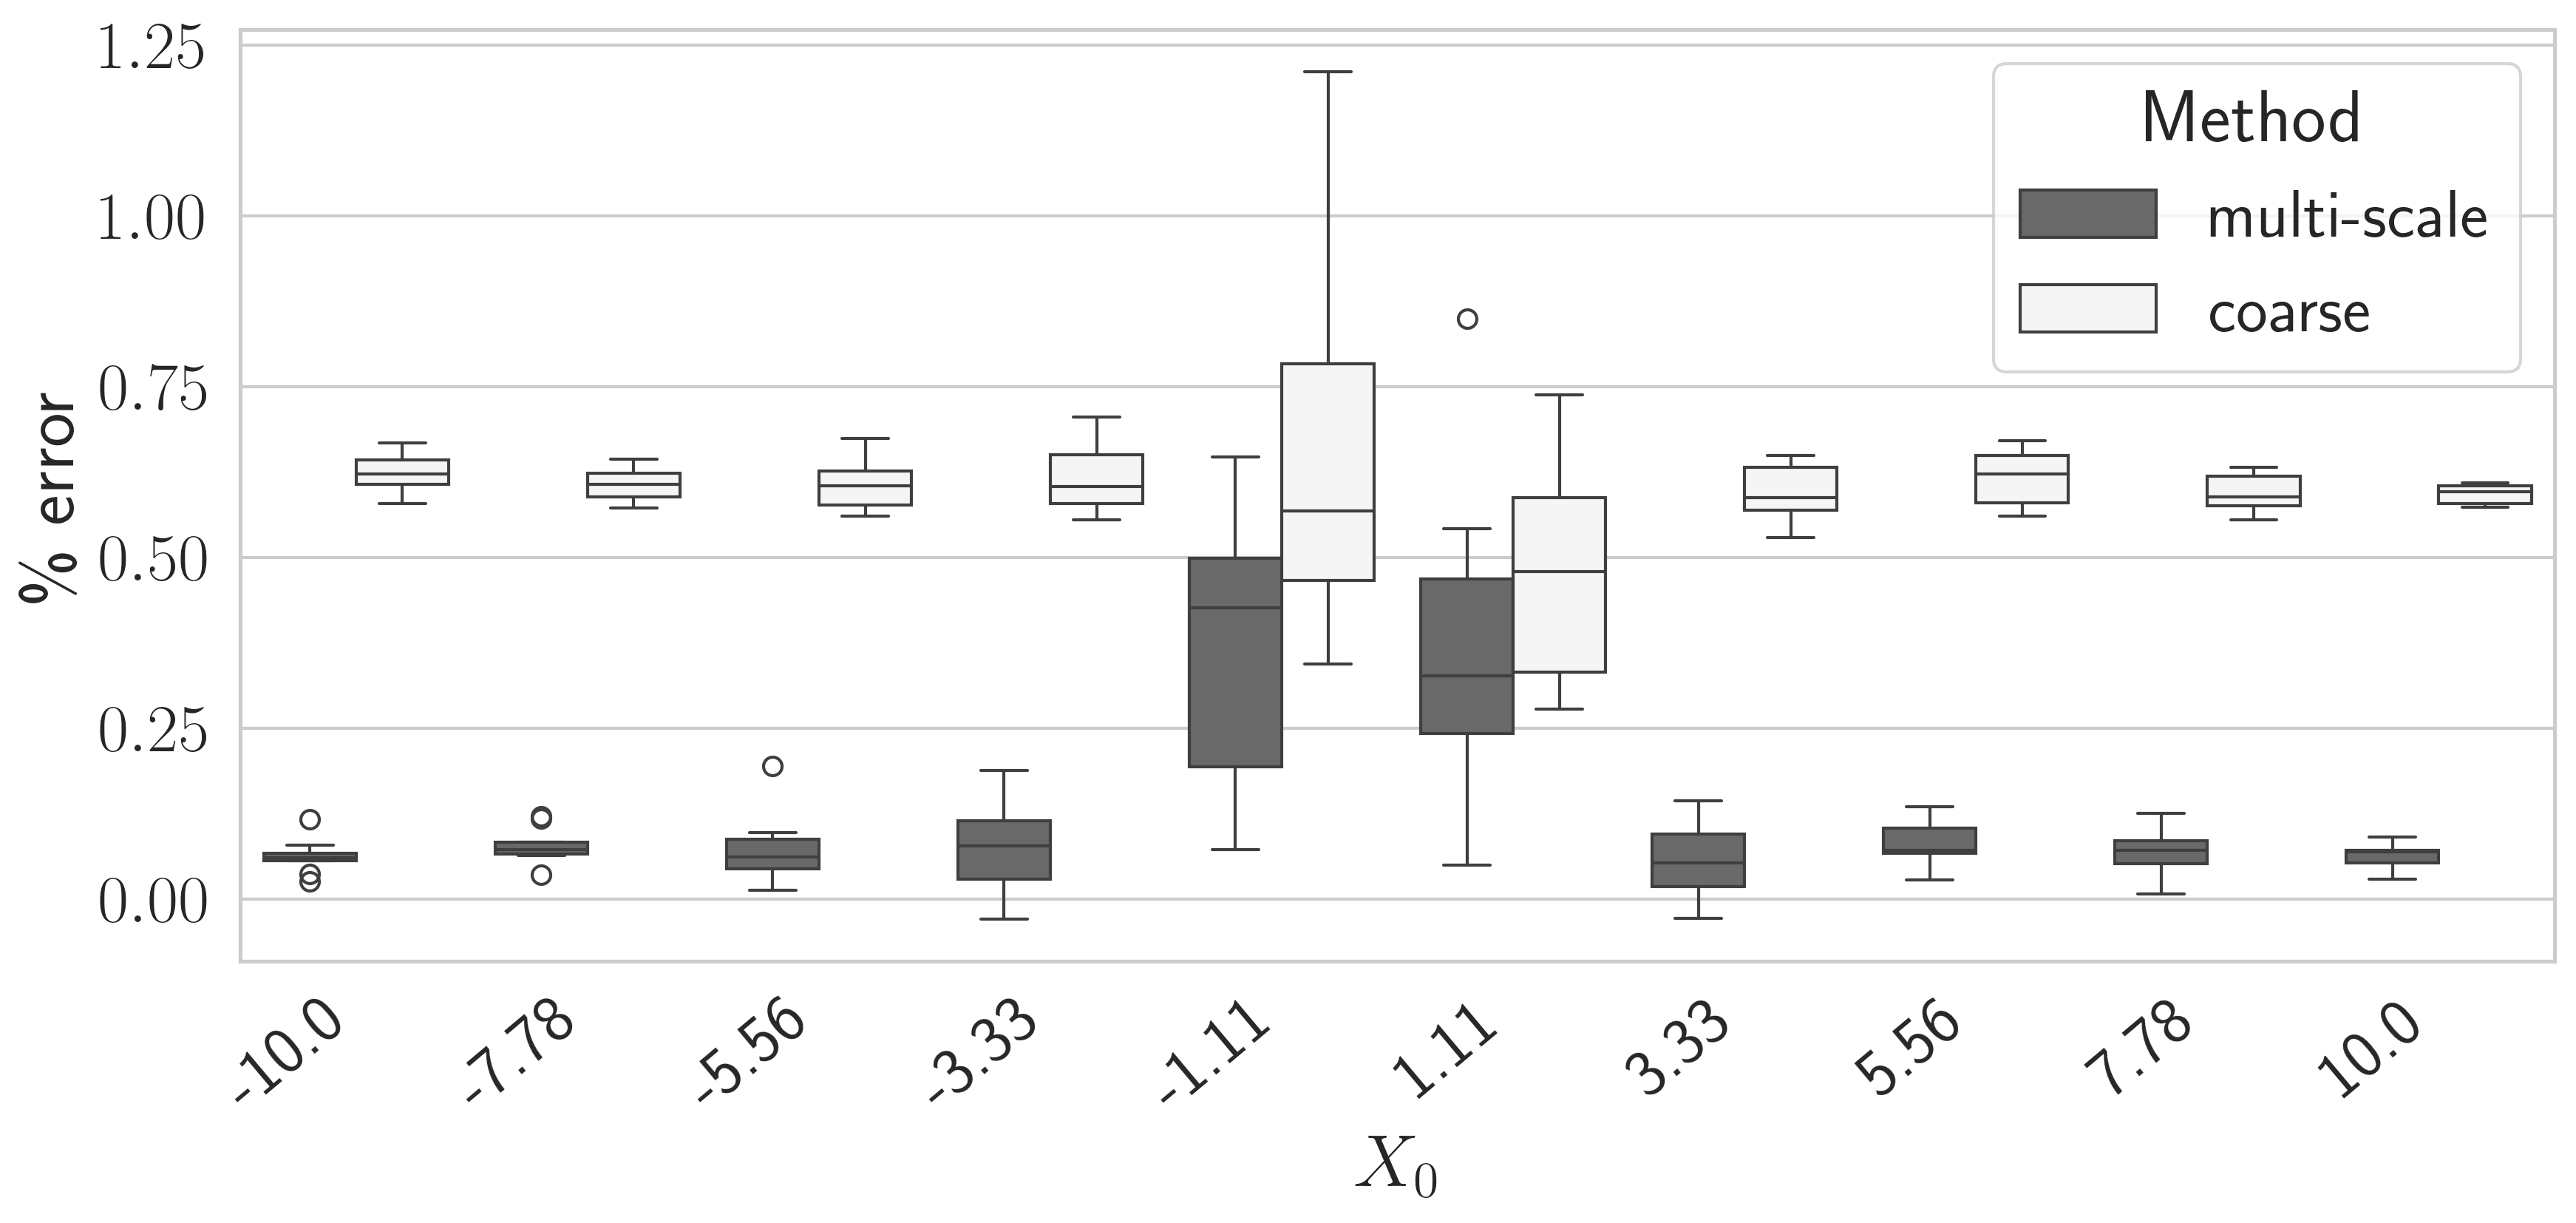

In [30]:
fig = plt.figure(figsize=(12,6),dpi=300);
sns.set_style("whitegrid");
g = sns.boxplot(data=df_box_msc, y = 'rel_error', x = 'x', hue='Method', palette=['dimgrey', 'whitesmoke']);#, boxprops=dict(facecolor='none'));
g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="right")
g.set_xlabel(r"$X_0$");
g.set_ylabel(r"\% error");
# g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="center");
plt.tight_layout();

Relative $L^1$ error $= 16.23\%$

Relative $L^2$ error $= 9.28\%$

Relative $L^\infty$ error $= 7.17\%$

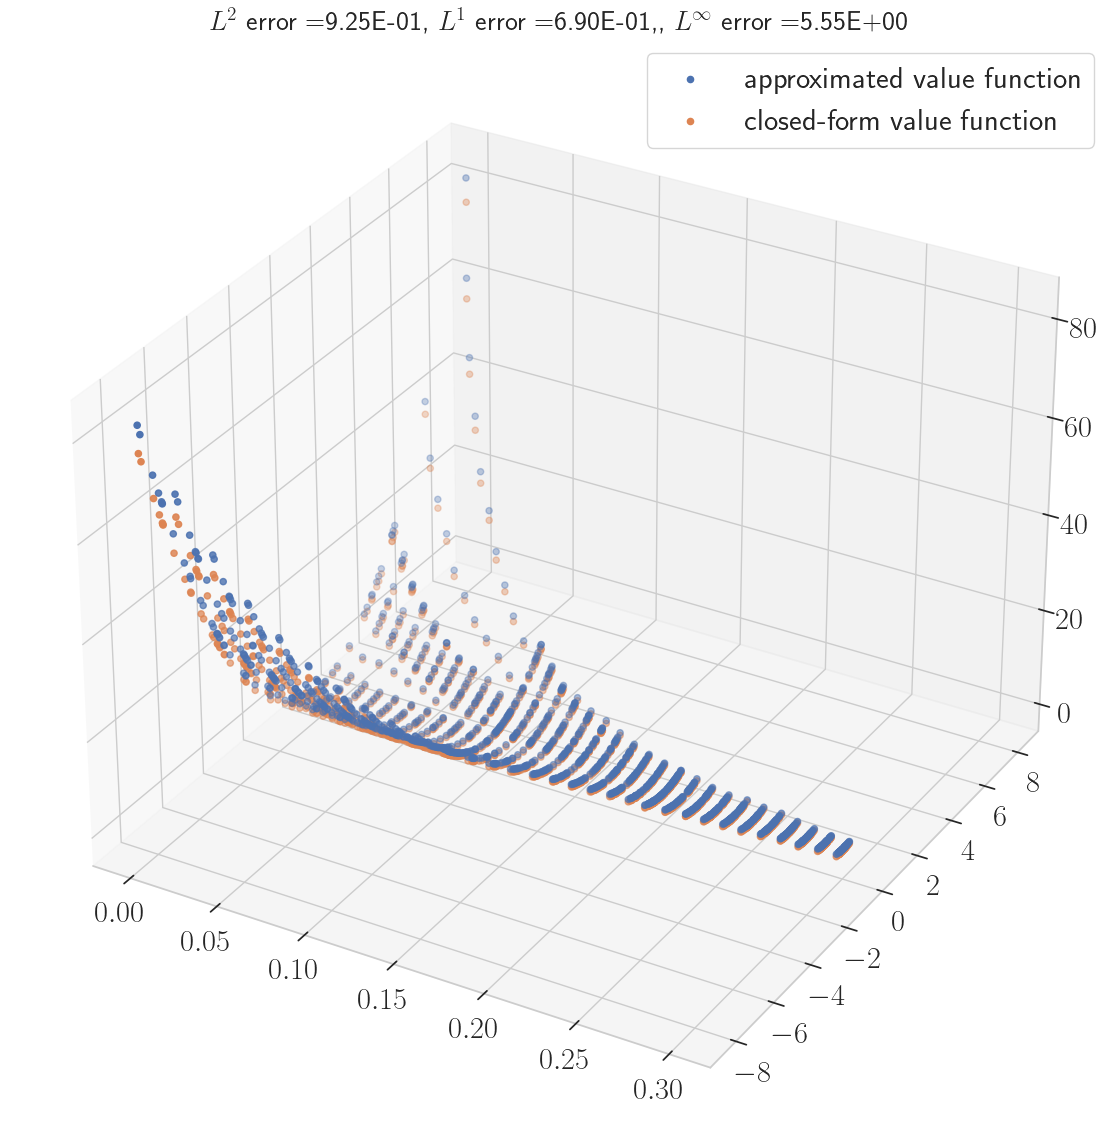

In [31]:
xyz = torch.concat((ms1.path,ms1(ms1.path).unsqueeze(-1)),dim=1).clone().detach().numpy()

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(projection='3d')
ax.scatter(xyz[:,0], xyz[:,1], xyz[:,2],label='approximated value function')
ax.scatter(xyz[:,0], xyz[:,1], solution(xyz[:,0:2]),label='closed-form value function')
ax.legend();
ax.set_title(r"$L^2$ error ={:.2E}, $L^1$ error ={:.2E},, $L^\infty$ error ={:.2E}".format(
    np.sqrt(np.mean(np.power(solution(xyz[:,0:2])-xyz[:,2],2))),
    np.mean(np.abs(solution(xyz[:,0:2])-xyz[:,2])),
    np.max(np.abs(solution(xyz[:,0:2])-xyz[:,2])),
    ), fontsize=20)
plt.tight_layout();

display(Markdown(r"Relative $L^1$ error $= {:.2f}\%$".format(np.mean(np.abs(solution(xyz[:,0:2])-xyz[:,2]))/np.mean(np.abs(solution(xyz[:,0:2])))*100)))
display(Markdown(r"Relative $L^2$ error $= {:.2f}\%$".format(np.sqrt(np.mean(np.power(solution(xyz[:,0:2])-xyz[:,2],2)))/np.sqrt(np.mean(np.power(solution(xyz[:,0:2]),2)))*100)))
display(Markdown(r"Relative $L^\infty$ error $= {:.2f}\%$".format(np.max(np.abs(solution(xyz[:,0:2])-xyz[:,2]))/np.max(np.abs(solution(xyz[:,0:2])))*100)))

# Brute-force

## Parameters

In [32]:
bf_model_params = {
    'num_samples':100,
    'num_time_steps':ms1.Num_steps,
    'num_neurons_p':50,
    'num_neurons_v':10,
    'lr' : 8e-3,
    'num_epochs' : 3000,
    'xmin' : model_params['xmin'],
    'xmax' : model_params['xmax'],
    'intervals' : None # a list of numbers between 0 to num_intervals-1
    }

## Instance creation

In [33]:
bf_lqsc = pgm(bf_model_params,lqsc_params, t1, value_eval=False)

## Training

In [34]:
bf_lqsc.train_it()

At epoch 0 the mean cost is 2253.223254206535.


At epoch 500 the mean cost is 41.168079176516805.


At epoch 1000 the mean cost is 41.165361703633835.


At epoch 1500 the mean cost is 41.16453731509384.


At epoch 2000 the mean cost is 41.16394278776992.


At epoch 2500 the mean cost is 41.16345804178526.


Training time= 59.03227496147156


In [35]:
# Log this run's wall-clock times and training stats to a JSON file, to average across runs
import json as _json
import os
import time as _time

overwrite_wallclock_log = False  # True: start a fresh log (this run becomes run #1); False: append to existing log

wallclock_log_path = "wallclock_log.json"

run_record = {
    "timestamp": _time.time(),

    "lqsc_policy_s": lqsc.train_time,
    "lqsc_policy_epochs": lqsc.train_epochs,
    "lqsc_policy_final_cost": lqsc.final_cost,

    "lqsc_value_s": lqsc_value_time_initial,
    "lqsc_value_epochs": lqsc_value_epochs_initial,
    "lqsc_value_final_loss": lqsc_value_final_loss_initial,

    "lqsc_value_retrain_s": lqsc.value_time,
    "lqsc_value_retrain_epochs": lqsc.value_epochs,
    "lqsc_value_retrain_final_loss": lqsc.final_value_loss,

    "ms1_policy_s": ms1.train_time,
    "ms1_policy_epochs": ms1.train_epochs,
    "ms1_policy_final_cost": ms1.final_cost,

    "bf_train_s": bf_lqsc.train_time,
    "bf_policy_epochs": bf_lqsc.train_epochs,
    "bf_policy_final_cost": bf_lqsc.final_cost,
}
run_record["total_s"] = (run_record["lqsc_policy_s"] + run_record["lqsc_value_s"]
                          + run_record["lqsc_value_retrain_s"] + run_record["ms1_policy_s"])

if overwrite_wallclock_log or not os.path.exists(wallclock_log_path):
    wallclock_log = {"num_runs": 0, "runs": []}
else:
    with open(wallclock_log_path, "r") as f:
        wallclock_log = _json.load(f)

wallclock_log["runs"].append(run_record)
wallclock_log["num_runs"] = len(wallclock_log["runs"])

numeric_keys = [k for k in run_record if k != "timestamp"]
wallclock_log["average"] = {
    key: sum(r[key] for r in wallclock_log["runs"]) / wallclock_log["num_runs"]
    for key in numeric_keys
}

with open(wallclock_log_path, "w") as f:
    _json.dump(wallclock_log, f, indent=2)

print(f"Logged run {wallclock_log['num_runs']} to {wallclock_log_path}")
print(f"Averages over {wallclock_log['num_runs']} run(s):")
for k, v in wallclock_log["average"].items():
    print(f"  {k}: {v:.4f}")

Logged run 21 to wallclock_log.json
Averages over 21 run(s):
  lqsc_policy_s: 5.9764
  lqsc_policy_epochs: 3000.0000
  lqsc_policy_final_cost: 61.6456
  lqsc_value_s: 0.9416
  lqsc_value_epochs: 2956.3333
  lqsc_value_final_loss: nan
  lqsc_value_retrain_s: 0.9827
  lqsc_value_retrain_epochs: 3078.5238
  lqsc_value_retrain_final_loss: 0.1564
  ms1_policy_s: 5.8761
  ms1_policy_epochs: 3000.0000
  ms1_policy_final_cost: 10.0771
  bf_train_s: 74.7557
  bf_policy_epochs: 3000.0000
  bf_policy_final_cost: 41.4277
  total_s: 13.7768


Using 20 of 21 runs (1 excluded as bf_train_s outlier)


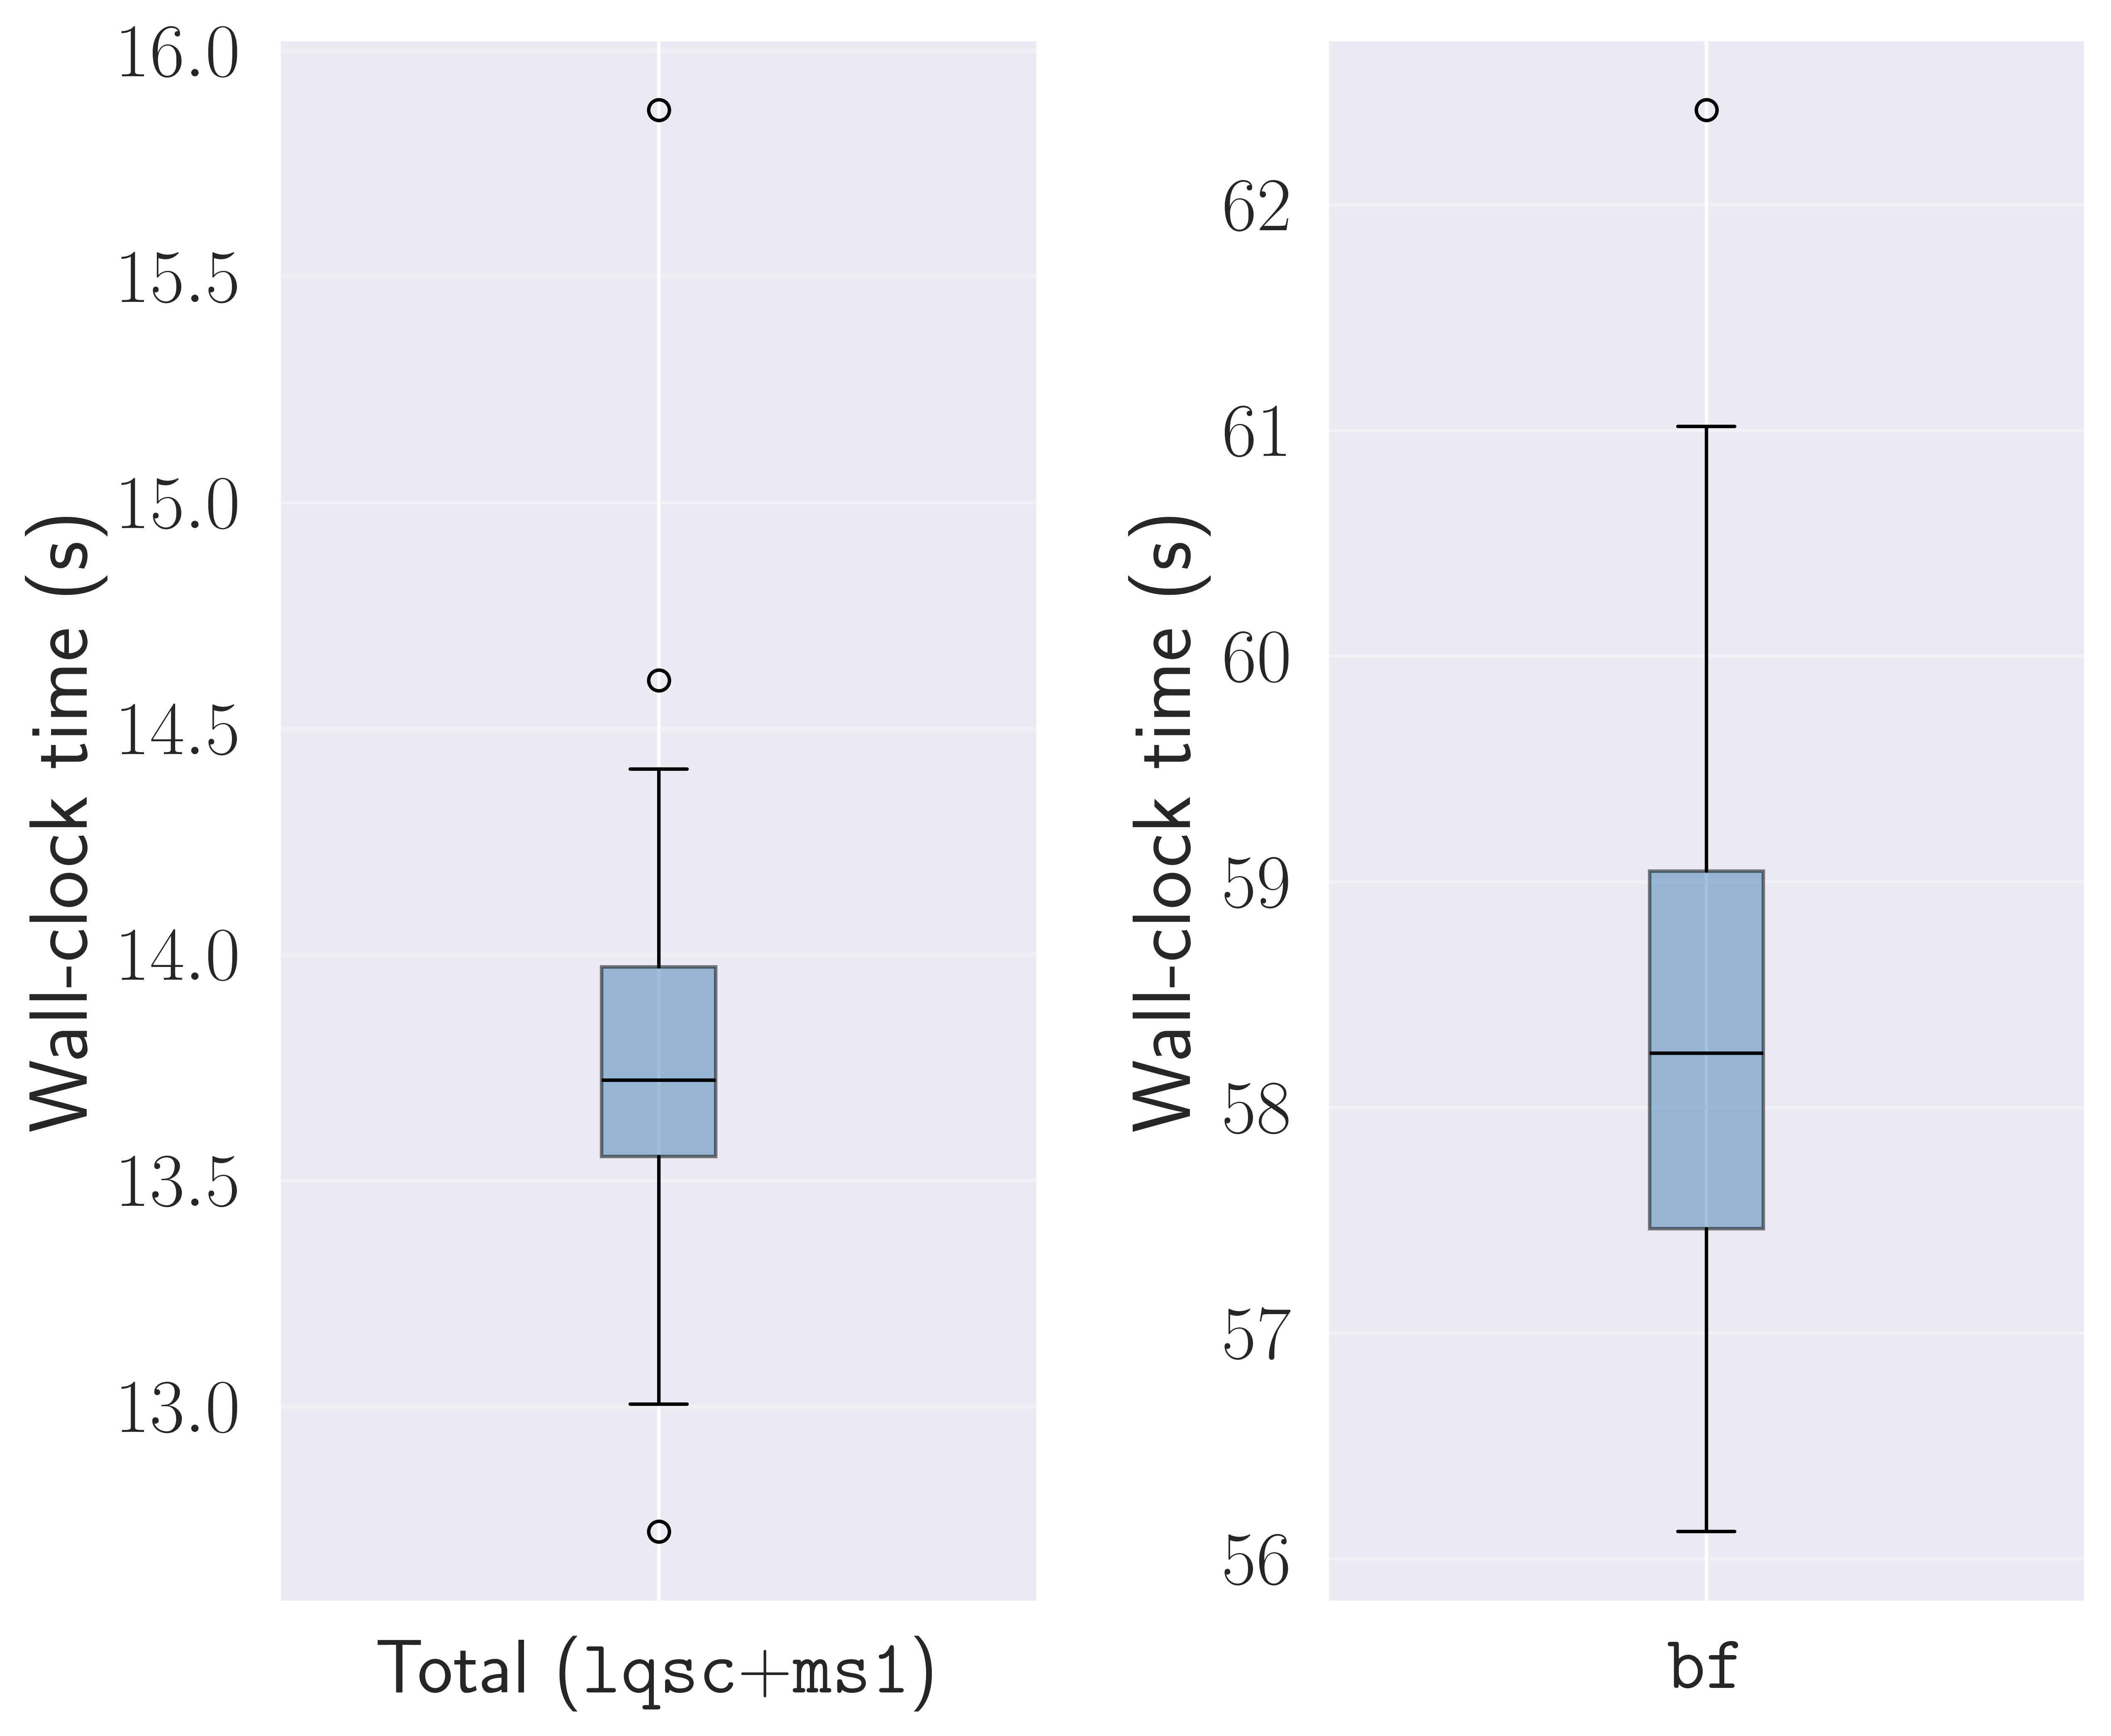

In [2]:
# Boxplot: Total (lqsc+ms1) vs bf, excluding the bf_train_s outlier run (>150s, clearly not typical)
# Each box gets its own y-axis (different scales -- avoids a dead gap on a shared axis)
import json as _json

with open('wallclock_log.json') as f:
    wallclock_log = _json.load(f)

all_runs = wallclock_log['runs']
runs = [r for r in all_runs if r['bf_train_s'] < 150]
n_excluded = len(all_runs) - len(runs)
print(f"Using {len(runs)} of {len(all_runs)} runs ({n_excluded} excluded as bf_train_s outlier)")

total_vals = [r['lqsc_policy_s'] + r['lqsc_value_s'] + r['lqsc_value_retrain_s'] + r['ms1_policy_s'] for r in runs]
bf_vals = [r['bf_train_s'] for r in runs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 7.5), dpi=600)

box_color = 'steelblue'
boxprops = dict(facecolor=box_color, alpha=0.5, edgecolor='black')
medianprops = dict(color='black')
whiskerprops = dict(color='black')
capprops = dict(color='black')

ax1.boxplot([total_vals], patch_artist=True,
            boxprops=boxprops, medianprops=medianprops,
            whiskerprops=whiskerprops, capprops=capprops,
            tick_labels=[r'Total ($\mathtt{lqsc}$+$\mathtt{ms1}$)'])
ax1.set_ylabel('Wall-clock time (s)')
ax1.grid(True, alpha=0.3, axis='y')

ax2.boxplot([bf_vals], patch_artist=True,
            boxprops=boxprops, medianprops=medianprops,
            whiskerprops=whiskerprops, capprops=capprops,
            tick_labels=[r'$\mathtt{bf}$'])
ax2.set_ylabel('Wall-clock time (s)')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('lqc_wallclock_boxplot.png', dpi=600, bbox_inches='tight')
plt.show()

In [36]:
dfv_bf = pd.DataFrame(np.zeros([K1*L,4]),columns=[1,'closed','C','MS']); 
for i,_ in dfv_bf.iterrows(): 
    # df_bf.loc[i,10] = bf_lqsc.cost_eval(lqsc.policy,3000,X[i%K],policy_update_lag=10).clone().detach().numpy()
    dfv_bf.loc[i,1] = bf_lqsc.cost_eval(bf_lqsc.policy,1,X1[i%K1]).clone().detach().numpy()
    dfv_bf.loc[i,'C'] = lqsc.cost_eval(lqsc.policy,1,X1[i%K1]).clone().detach().numpy()
    dfv_bf.loc[i,'MS'] = ms1.cost_eval(ms1.policy,1,X1[i%K1]).clone().detach().numpy()
dfv_bf['closed'] = list(solution(tx1))*L
dfv_bf['index'] = [str(np.round(x,3)) for x in X1.clone().detach().numpy()]*L
dfv_bf.set_index('index',inplace=True,drop=True)    
dfv_bf.rename(columns={1:'brute-force', 'closed':'closed-form','C':'coarse', 'MS': 'multi-scale'},inplace=True)


/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/1048887168.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.f_func = lambda t: -1/q2*(lb1*np.exp(lb1*(self.T-t))+C1*lb2*np.exp(lb2*(self.T-t)))/(np.exp(lb1*(self.T-t))+C1*np.exp(lb2*(self.T-t)))
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/1048887168.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.array([self.f_func(tx[i,0])*np.power(tx[i,1],2)+self.h_func(tx[i,0])*tx[i,1]+self.k_func(tx[i,0]) for i in range(tx.shape[0])])
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/1048887168.py:34: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.h_func = lambda t: (self.b*((1/(lb1-self.c))*np.exp(lb

/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/389854110.py:3: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  g = sns.lineplot(data=dfv_bf, palette=['dimgrey', 'lightgrey', 'black']);


/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/389854110.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(list(np.round(X1.clone().detach().numpy(),2)));
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/389854110.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="right")


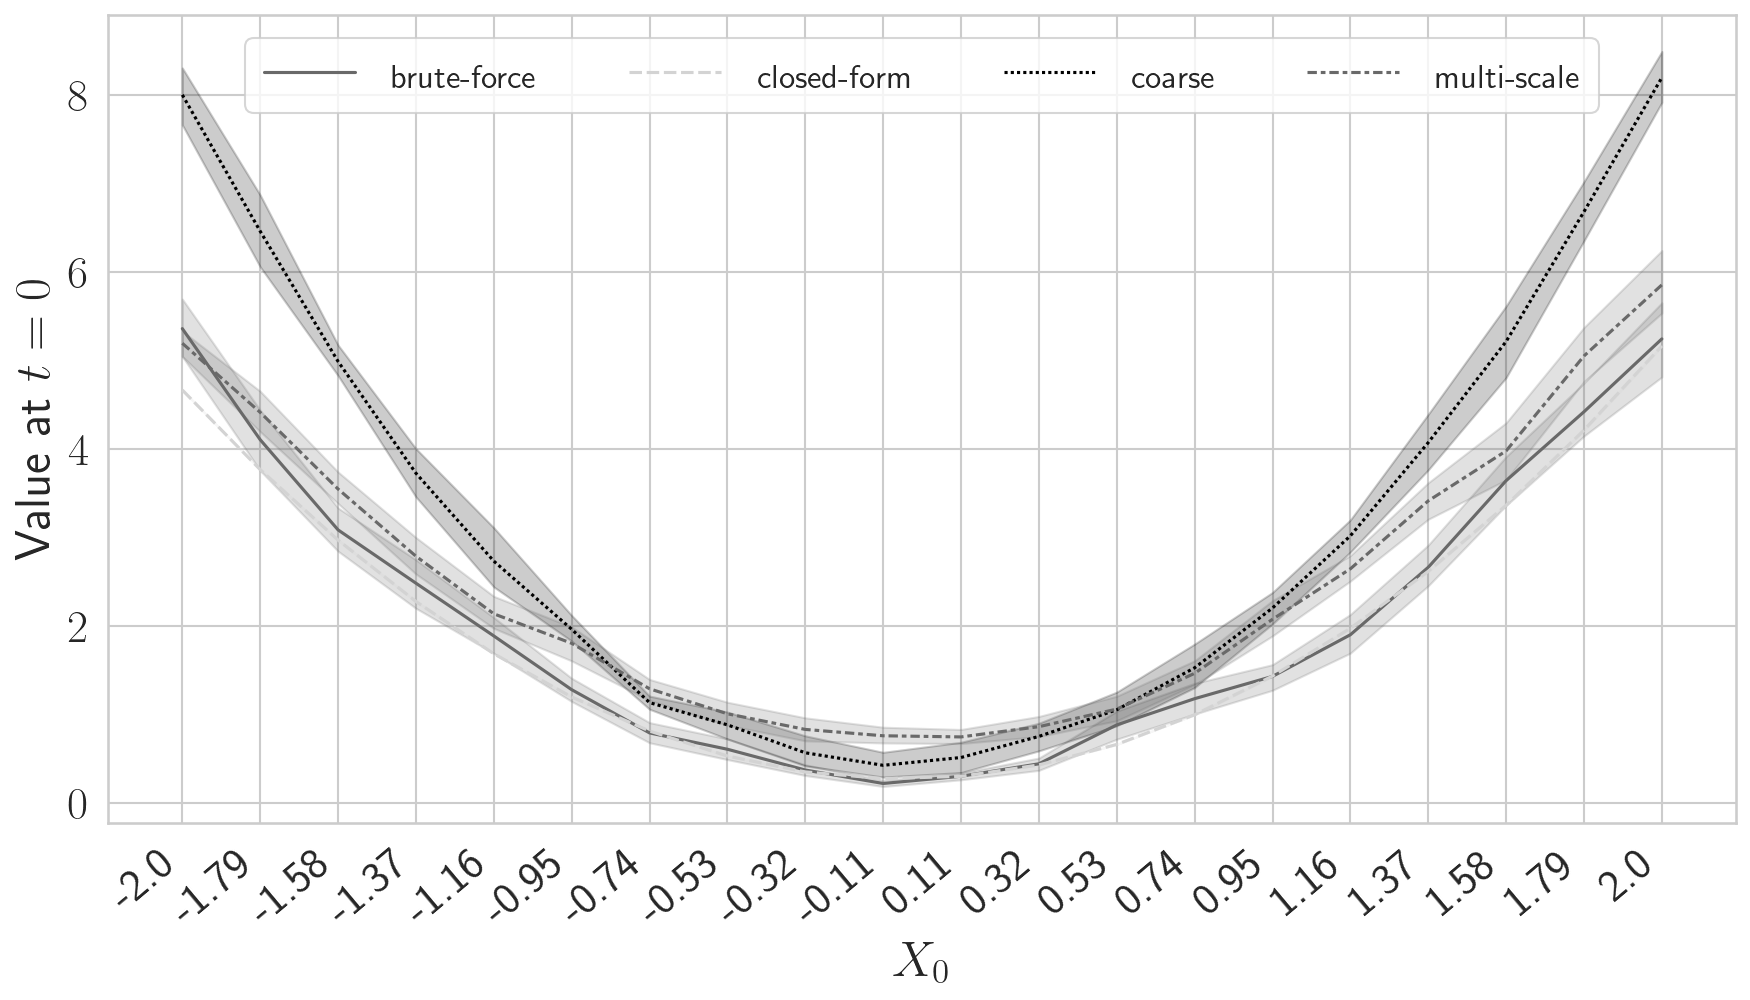

In [37]:
plt.figure(figsize=(14,7),dpi=150);
sns.set_style("whitegrid");
g = sns.lineplot(data=dfv_bf, palette=['dimgrey', 'lightgrey', 'black']);
g.set_xticklabels(list(np.round(X1.clone().detach().numpy(),2)));
g.set_xlabel(r"$X_0$");
g.set_ylabel(r"Value at $t=0$");
sns.move_legend(g, "upper center", bbox_to_anchor=(.5, 1.), ncol=4, title=None)
plt.setp(g.get_legend().get_texts(), fontsize='16') # for legend text
plt.setp(g.get_legend().get_title(), fontsize='12') # for legend title
g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="right")
s1 = str(model_params['num_samples'])
s2 = str(ms1_model_params['num_samples'])
plt.savefig("bf_"+s1+"_"+s2+version+".png")

In [38]:
df_bf = pd.DataFrame(np.zeros([K*L,4]),columns=[1,'closed','C','MS']); 
for i,_ in df_bf.iterrows(): 
    # df_bf.loc[i,10] = bf_lqsc.cost_eval(lqsc.policy,3000,X[i%K],policy_update_lag=10).clone().detach().numpy()
    df_bf.loc[i,1] = bf_lqsc.cost_eval(bf_lqsc.policy,1,X[i%K]).clone().detach().numpy()
    df_bf.loc[i,'C'] = lqsc.cost_eval(lqsc.policy,1,X[i%K]).clone().detach().numpy()
    df_bf.loc[i,'MS'] = ms1.cost_eval(ms1.policy,1,X[i%K]).clone().detach().numpy()
df_bf['closed'] = list(solution(tx))*L
df_bf['index'] = [str(np.round(x,3)) for x in X.clone().detach().numpy()]*L
df_bf.set_index('index',inplace=True,drop=True)    
df_bf

/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/1048887168.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.f_func = lambda t: -1/q2*(lb1*np.exp(lb1*(self.T-t))+C1*lb2*np.exp(lb2*(self.T-t)))/(np.exp(lb1*(self.T-t))+C1*np.exp(lb2*(self.T-t)))
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/1048887168.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.array([self.f_func(tx[i,0])*np.power(tx[i,1],2)+self.h_func(tx[i,0])*tx[i,1]+self.k_func(tx[i,0]) for i in range(tx.shape[0])])
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/1048887168.py:34: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.h_func = lambda t: (self.b*((1/(lb1-self.c))*np.exp(lb

,1,closed,C,MS
index,,,,
-10.0,119.963103,115.141822,180.635965,121.700216
-7.778,73.228163,69.544915,109.872503,71.131326
-5.556,34.815782,35.416525,57.558781,36.734875
-3.333,13.820011,12.756653,20.777525,13.967435
-1.111,2.001620,1.565299,2.818810,1.872460
...,...,...,...,...
1.111,1.828785,1.842462,3.097749,2.108110
3.333,14.336358,13.588143,21.429242,15.773415
5.556,40.919350,36.802342,57.174807,37.320676


In [39]:
df_box_bf = ((df_bf[1]-df_bf['closed'])/df_bf['closed']).reset_index()
df_box_bf.columns = ['x', 'rel_error']
df_box_bf['Method'] = 'brute-force'
df_box_bfmsc = pd.concat([df_box_bf,df_box_msc],axis=0)
df_box_bfmsc

,x,rel_error,Method
0,-10.0,0.041873,brute-force
1,-7.778,0.052962,brute-force
2,-5.556,-0.016962,brute-force
3,-3.333,0.083357,brute-force
4,-1.111,0.278746,brute-force
...,...,...,...
95,1.111,0.545929,coarse
96,3.333,0.649289,coarse
97,5.556,0.573137,coarse
98,7.778,0.555693,coarse


/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_55204/4161798416.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="right")


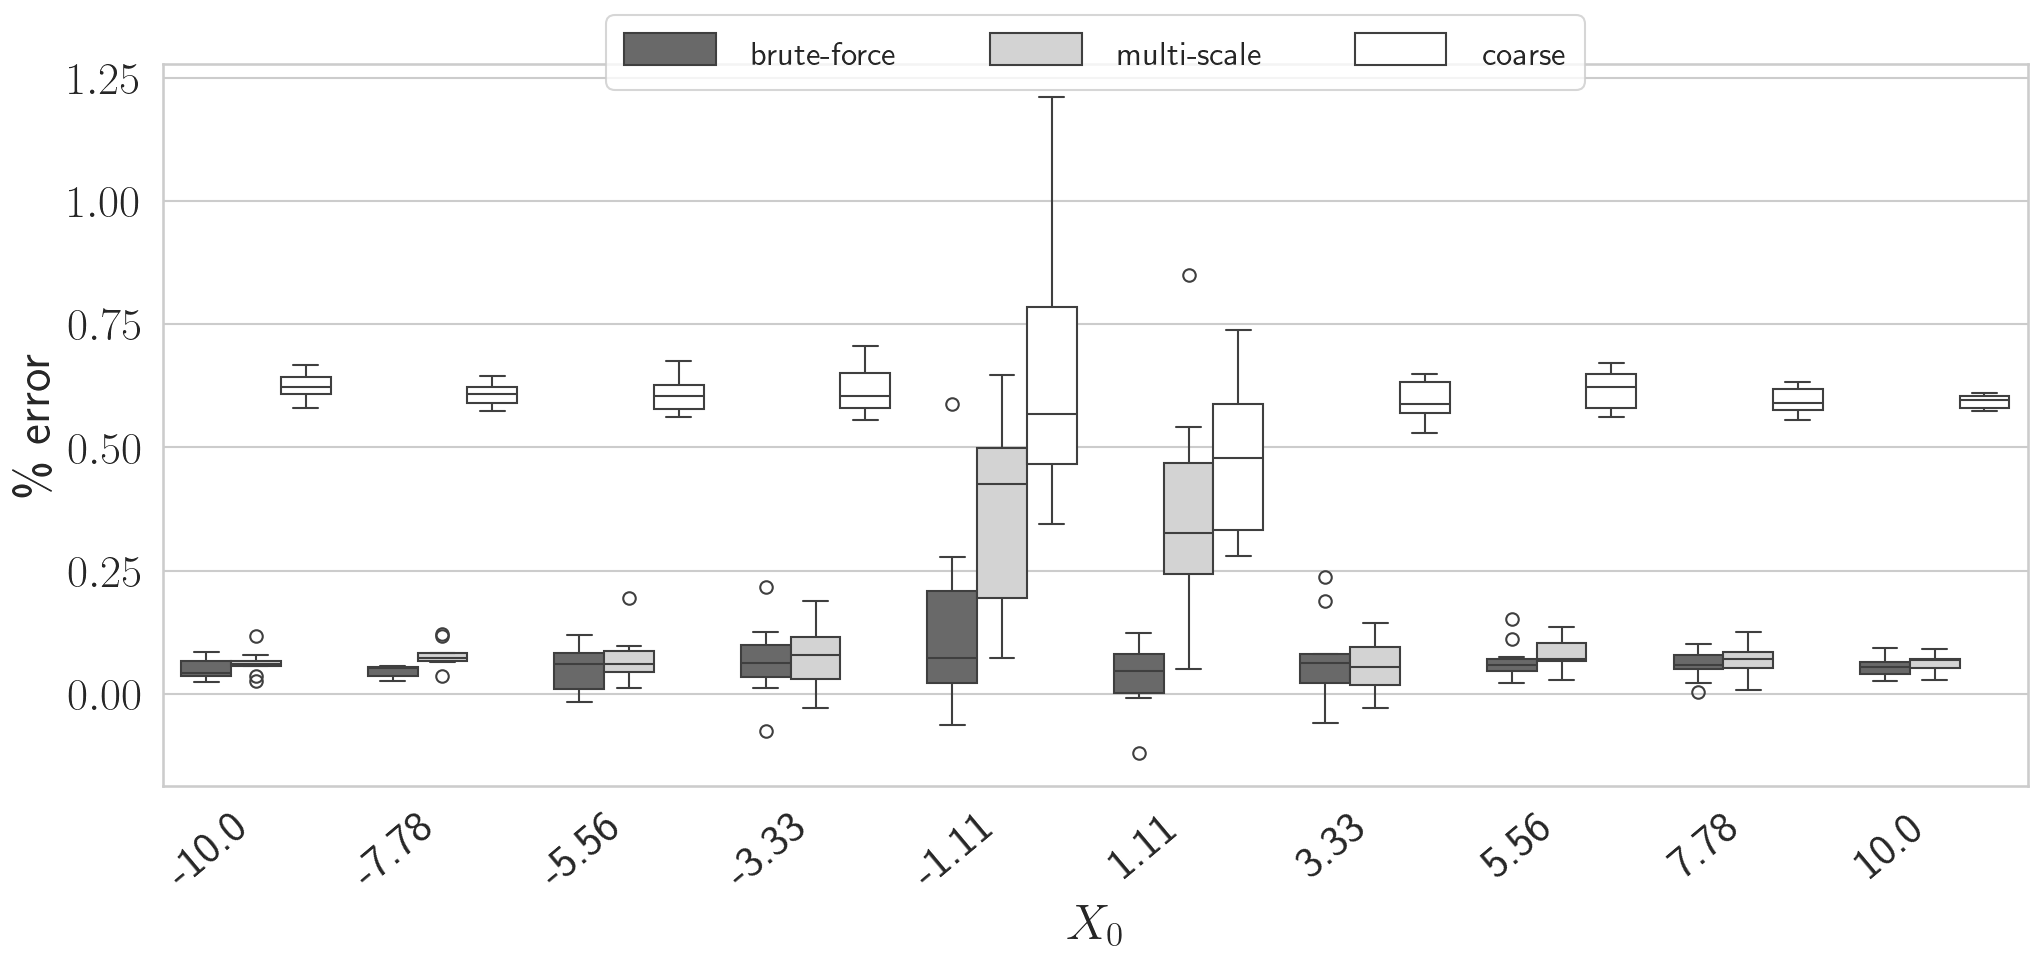

In [40]:
fig = plt.figure(figsize=(14,7),dpi=150);
sns.set_style("whitegrid");
g = sns.boxplot(data=df_box_bfmsc, y = 'rel_error', x = 'x', hue='Method', palette=['dimgrey', 'lightgrey', 'white']);#, boxprops=dict(facecolor='none'));
g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="right")
g.set_xlabel(r"$X_0$");
g.set_ylabel(r"\% error");
sns.move_legend(g, "upper center", bbox_to_anchor=(.5, 1.1), ncol=3, title=None)
plt.setp(g.get_legend().get_texts(), fontsize='16') # for legend text
plt.setp(g.get_legend().get_title(), fontsize='12') # for legend title
plt.tight_layout();
plt.savefig("rel_{}_{}_Comparison_bf_ms_coarse{}.png".format(model_params['num_samples'],ms1_model_params['num_samples'],version));
plt.savefig("rel_{}_{}_Comparison_bf_ms_coarse{}.pdf".format(model_params['num_samples'],ms1_model_params['num_samples'],version), format='pdf');

In [41]:
print("rel_{}_{}_Comparison_bf_ms_coarse{}.pdf".format(model_params['num_samples'],ms1_model_params['num_samples'],version))

rel_100_50_Comparison_bf_ms_coarse_7.pdf
